# Midterm exam

## Business Context

Today, you will analyze a well-known phenomenon in Peruvian football and, more broadly, in Peruvian society. This phenomenon is called `brutalidad`, which refers to expressing opinions, especially football-related opinions, in a rather impolite and even rude manner. You can find more information about this phenomenon in this [video](https://www.youtube.com/watch?v=G9vVfLuuVmo).

A classic episode of `brutalidad` is the February 14, 2024 episode of **El Show Deportivo**. In my humble opinion, this episode perfectly represents this movement. In this sense, one of the most interesting resources used by the panelists is sarcasm.

The objective of the exam will be to use this data and apply the algorithms seen in class.

> **Disclaimer:** The professor does not necessarily agree with the opinions, expressions, or statements presented in the video or in the data used for this exam. The material is provided strictly for academic and analytical purposes.

## Dataset Facts To Give Students

These facts make the exam grounded and difficult to answer with generic explanations.

- Records: `1,162`
- Label distribution: `1,110` non-sarcastic, `52` sarcastic
- Positive rate: approximately `4.48%`
- Majority-class accuracy: approximately `95.52%`
- `note` is present for all `52` sarcastic records and absent for all non-sarcastic records.
- Average segment duration: approximately `5.28` seconds
- Average frame count per record: approximately `2.84`
- Referenced unique frame files: `3,296`
- Available frame files in folder: `3,704`
- Referenced frames appear to be present, but there are extra frame files not referenced by the JSONL.
- Sampled frames are JPEG images with resolution `1280x720`.
- Adjacent transcript windows overlap heavily in time: `1,030` adjacent overlaps were found.
- JSON frame paths use `output/frames/...`; actual local frame folder must be joined by frame basename.


## Dataset Loading

Run **one** of the two options below before answering the questions.

The main file is `sarcasm_multimodal_dataset.jsonl`. Each JSON record includes transcript metadata and a `frames` list. The JSON paths use `output/frames/...`, but in this exam repository the images are matched by frame filename inside the `frames` folder.

Do not use `label`, `confidence`, or `note` as unsupervised model features. They are loaded only for validation, diagnostics, and business interpretation questions.

You can find the dataset [here](https://drive.google.com/drive/folders/1S7ioFPCMd0EMZzs6bKf1idd2G5rOEbHa?usp=sharing)

In [1]:
from pathlib import Path
import json

JSONL_NAME = "sarcasm_multimodal_dataset.jsonl"
FRAMES_FOLDER = "frames"


def resolve_frame_path(frame_info: dict, frames_dir: Path) -> Path:
    """Map one JSON frame entry to the actual image path in frames_dir."""
    frame_name = frame_info.get("frame")
    if frame_name is None:
        frame_name = Path(frame_info["path"]).name
    return frames_dir / Path(frame_name).name


def load_sarcasm_dataset(data_dir: str | Path) -> tuple[list[dict], Path, Path]:
    """Load the JSONL records and attach resolved local image paths.

    Returns:
    - records: list of dictionaries loaded from JSONL.
    - jsonl_path: path to the JSONL file used.
    - frames_dir: folder containing the JPEG frames.
    """
    data_dir = Path(data_dir).expanduser()
    jsonl_path = data_dir / JSONL_NAME
    frames_dir = data_dir / FRAMES_FOLDER

    if not jsonl_path.exists():
        raise FileNotFoundError(f"JSONL file not found: {jsonl_path.resolve()}")
    if not frames_dir.exists():
        raise FileNotFoundError(f"Frames folder not found: {frames_dir.resolve()}")

    records = []
    with jsonl_path.open("r", encoding="utf-8") as file:
        for line in file:
            record = json.loads(line)
            record["resolved_frame_paths"] = [
                resolve_frame_path(frame, frames_dir)
                for frame in record.get("frames", [])
            ]
            records.append(record)

    referenced_frames = {
        path.name
        for record in records
        for path in record["resolved_frame_paths"]
    }
    available_frames = {path.name for path in frames_dir.glob("*.jpg")}
    missing_frames = sorted(referenced_frames - available_frames)
    extra_frames = sorted(available_frames - referenced_frames)

    label_counts = {}
    for record in records:
        label = record.get("label")
        label_counts[label] = label_counts.get(label, 0) + 1

    print(f"JSONL path: {jsonl_path}")
    print(f"Frames folder: {frames_dir}")
    print(f"Records: {len(records)}")
    print(f"Label counts: {label_counts}")
    print(f"Referenced unique frames: {len(referenced_frames)}")
    print(f"Available JPEG frames: {len(available_frames)}")
    print(f"Missing referenced frames: {len(missing_frames)}")
    print(f"Extra unreferenced JPEG frames: {len(extra_frames)}")

    if records:
        print("First record id:", records[0].get("id"))
        print("First record text:", records[0].get("text"))
        print("First resolved frame path:", records[0]["resolved_frame_paths"][0] if records[0]["resolved_frame_paths"] else None)

    return records, jsonl_path, frames_dir


### Option 1: Local Repository

Use this option when the notebook is running from this repository or from the `big_data_course_content/exams` folder. It checks both `big_data_course_content/exam/data` and the current repository layout, `big_data_course_content/data`.


In [2]:
LOCAL_DATA_CANDIDATES = [
    Path("big_data_course_content/exam/data"),
    Path("big_data_course_content/data"),
    Path("exam/data"),
    Path("../data"),
    Path("data"),
]

DATA_DIR = next(
    (
        candidate
        for candidate in LOCAL_DATA_CANDIDATES
        if (candidate / JSONL_NAME).exists() and (candidate / FRAMES_FOLDER).exists()
    ),
    LOCAL_DATA_CANDIDATES[0],
)

records, jsonl_path, frames_dir = load_sarcasm_dataset(DATA_DIR)


JSONL path: data\sarcasm_multimodal_dataset.jsonl
Frames folder: data\frames
Records: 1162
Label counts: {0: 1110, 1: 52}
Referenced unique frames: 3296
Available JPEG frames: 3703
Missing referenced frames: 0
Extra unreferenced JPEG frames: 407
First record id: 0
First record text: [Música]
First resolved frame path: data\frames\frame_0003.jpg


### Option 2: Google Drive

Use this option in Google Colab after copying the dataset folder to Drive. Change `DRIVE_DATA_DIR` if your folder has a different location.


In [ ]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
except ModuleNotFoundError:
    print("google.colab is only available in Colab. Set DRIVE_DATA_DIR manually if needed.")

DRIVE_DATA_DIR = Path("/content/drive/MyDrive/big_data_course_content/data")

records, jsonl_path, frames_dir = load_sarcasm_dataset(DRIVE_DATA_DIR)


## Raw NumPy Arrays for Modeling

Run this section after loading the dataset from the local repository or Google Drive.

The variables created here keep the raw modalities available for model training:

- `X_text_raw`: raw transcript text for every record, shape `(n,)`.
- `X_image_raw`: raw RGB pixel arrays from one selected frame per record, shape `(n, height, width, 3)`.
- `X_frame_paths_raw`: selected image path per record, shape `(n,)`.
- `X` and `X_raw`: object arrays with `[text, image]` per row, shape `(n, 2)`. The text is always in `X[:, 0]`; the image array is always in `X[:, 1]`.
- `y`: labels, shape `(n,)`.

The first records in this dataset are `[Música]`, so the preview prints the first 10 text rows and the first non-`[Música]` row to verify that all transcript text is preserved.

By default, images are resized to `224x224` only to make a single NumPy tensor possible and avoid loading full 1280x720 frames into memory. Set `IMAGE_SIZE = None` only if you want the original image resolution and have enough memory.


In [3]:
import numpy as np

try:
    from PIL import Image
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "Pillow is required to load JPEG images. Install it with: pip install pillow"
    ) from exc


def choose_record_frame_path(record: dict, strategy: str = "middle") -> Path | None:
    """Choose one frame path from a record for image-based modeling."""
    frame_paths = record.get("resolved_frame_paths", [])
    if not frame_paths:
        return None
    if strategy == "first":
        return frame_paths[0]
    if strategy == "last":
        return frame_paths[-1]
    if strategy == "middle":
        return frame_paths[len(frame_paths) // 2]
    raise ValueError("strategy must be 'first', 'middle', or 'last'")


def load_rgb_image(path: str | Path, image_size: tuple[int, int] | None = (224, 224)) -> np.ndarray:
    """Load one image as an RGB uint8 array with shape (height, width, 3)."""
    with Image.open(path) as image:
        image = image.convert("RGB")
        if image_size is not None:
            image = image.resize(image_size)
        return np.asarray(image, dtype=np.uint8)


def build_raw_model_arrays(
    records: list[dict],
    image_size: tuple[int, int] | None = (224, 224),
    frame_strategy: str = "middle",
    max_records: int | None = None,
) -> dict[str, np.ndarray]:
    """Build raw multimodal NumPy arrays from text, selected frames, and labels.

    X has shape (n, 2):
    - X[:, 0] contains the raw text for every record.
    - X[:, 1] contains the selected raw image array for the same record.

    The label array is included for supervised training/evaluation. Do not use
    label, confidence, or note as unsupervised features.
    """
    selected_records = records[:max_records] if max_records is not None else records
    if not selected_records:
        raise ValueError("records is empty")

    selected_frame_paths = [
        choose_record_frame_path(record, strategy=frame_strategy)
        for record in selected_records
    ]
    missing_frame_records = [
        record.get("id")
        for record, path in zip(selected_records, selected_frame_paths)
        if path is None or not Path(path).exists()
    ]
    if missing_frame_records:
        preview = missing_frame_records[:10]
        raise FileNotFoundError(
            f"Some records do not have an available selected frame. First missing ids: {preview}"
        )

    X_text_raw = np.asarray(
        [record.get("text", "") for record in selected_records],
        dtype=object,
    )
    X_frame_paths_raw = np.asarray(
        [str(path) for path in selected_frame_paths],
        dtype=object,
    )
    X_image_raw = np.stack(
        [load_rgb_image(path, image_size=image_size) for path in selected_frame_paths],
        axis=0,
    )
    y = np.asarray(
        [record["label"] for record in selected_records],
        dtype=np.int64,
    )

    X_raw = np.empty((len(selected_records), 2), dtype=object)
    for row_index, (text, image) in enumerate(zip(X_text_raw, X_image_raw)):
        X_raw[row_index, 0] = text
        X_raw[row_index, 1] = image

    if list(X_raw[:, 0]) != list(X_text_raw):
        raise AssertionError("Text was not preserved correctly in X_raw[:, 0]")

    return {
        "X": X_raw,
        "X_raw": X_raw,
        "X_text_raw": X_text_raw,
        "X_image_raw": X_image_raw,
        "X_frame_paths_raw": X_frame_paths_raw,
        "y": y,
    }


IMAGE_SIZE = (224, 224)
FRAME_STRATEGY = "middle"

raw_arrays = build_raw_model_arrays(
    records,
    image_size=IMAGE_SIZE,
    frame_strategy=FRAME_STRATEGY,
)

X = raw_arrays["X"]
X_raw = raw_arrays["X_raw"]
X_text_raw = raw_arrays["X_text_raw"]
X_image_raw = raw_arrays["X_image_raw"]
X_frame_paths_raw = raw_arrays["X_frame_paths_raw"]
y = raw_arrays["y"]

unique_text_count = len(set(X_text_raw.tolist()))
non_music_indices = [
    index
    for index, text in enumerate(X_text_raw)
    if str(text).strip() != "[Música]"
]

print("X shape:", X.shape, X.dtype)
print("X_raw shape:", X_raw.shape, X_raw.dtype)
print("X_text_raw shape:", X_text_raw.shape, X_text_raw.dtype)
print("X_image_raw shape:", X_image_raw.shape, X_image_raw.dtype)
print("X_frame_paths_raw shape:", X_frame_paths_raw.shape, X_frame_paths_raw.dtype)
print("y shape:", y.shape, y.dtype)
print("Unique text values:", unique_text_count)
print("First 10 text rows:")
for index, text in enumerate(X_text_raw[:10]):
    print(index, repr(text))
if non_music_indices:
    first_non_music = non_music_indices[0]
    print("First non-[Música] row:", first_non_music, repr(X_text_raw[first_non_music]))
print("First selected frame path:", X_frame_paths_raw[0])
print("First image min/max:", int(X_image_raw[0].min()), int(X_image_raw[0].max()))


X shape: (1162, 2) object
X_raw shape: (1162, 2) object
X_text_raw shape: (1162,) object
X_image_raw shape: (1162, 224, 224, 3) uint8
X_frame_paths_raw shape: (1162,) object
y shape: (1162,) int64
Unique text values: 1130
First 10 text rows:
0 '[Música]'
1 '[Música]'
2 'y de esta manera ponemos punto final a'
3 'esta edición de bes cable esport'
4 'noticias continúen disfrutando de la'
5 'programación de bes cable porque ya se'
6 'viene Ah el show deportivo nos vemos en'
7 'fútbol am chao'
8 'chao'
9 '[Música]'
First non-[Música] row: 2 'y de esta manera ponemos punto final a'
First selected frame path: data\frames\frame_0006.jpg
First image min/max: 0 255


### Optional: All Frame Paths Per Record

Use this when a model needs every frame referenced by each record. This keeps paths in an object array and does not load all images into memory.


In [ ]:
X_all_frame_paths_raw = np.asarray(
    [
        np.asarray([str(path) for path in record.get("resolved_frame_paths", [])], dtype=object)
        for record in records
    ],
    dtype=object,
)

print("X_all_frame_paths_raw shape:", X_all_frame_paths_raw.shape, X_all_frame_paths_raw.dtype)
print("First record frame paths:", X_all_frame_paths_raw[0])


## Exam Design Principles

Use these constraints to make the exam difficult even with AI assistance.

- Require mathematical derivations, not only definitions.
- Require students to connect each formula to a concrete dataset decision.
- Penalize any answer that uses `confidence`, `note`, or label-derived metadata as model features. Only use text or images.
- Require students to distinguish visualization, clustering, prediction, and business action.
- Require negative conclusions. A strong student must be willing to say "this evidence is not sufficient."
- Require explicit units: record, frame, timestamp window, speaker turn, video segment, or business event.
- Require operational outcomes: precision at review budget, moderation cost, missed-sarcasm risk, false-escalation risk.
- Students are allowed to use `sklearn` or any other library except `numpy`, `polars`, `pandas` and `itertools` if the question explicitely says that, otherwise it is forbidden.
- If there are performance issues due to high dimensionality of data, sampling and other methods are allowed. Just explain what you did.
- You must use data from images and text.
- If something is not clear, you can use assumptions but make them explicit.
- You must submit the notebook with outputs visible. Otherwise, you will get 0 in that question.
- In order an answer to be valid, the code for that question must run, otherwise, there will be no score for that question. Code itself is not graded but it is mandatory to have a valid grade.

**Important**

Any vague answer like "this is good because it is good" are going to invalidate the score in the whole question. Conclusions must be based on data and especific enough, using always business terms (check business context section) and linking to subjects revised in class.

## Section A - PCA, SVD, t-SNE, Distances, Scaling, and Clustering From Scratch 

Code rules for this section:

- Use only `numpy` and the Python standard library.
- Do not use `scikit-learn`, `scipy`, `pandas`, `torch`, `tensorflow`, or automatic differentiation.
- Do not call high-level implementations of the target algorithm. `np.linalg.eigh` is allowed for eigen-decomposition checks; `np.linalg.svd` is allowed only when the question explicitly asks for a comparison.
- Every code answer must include shape annotations, numerical-stability safeguards, and a written link between the code and the matrix formula.
- Hidden tests should change `n`, `d`, scale, class balance, random seed, metric, and number of components. Hard-coded constants should fail.
- Fields `label`, `confidence`, and `note` must not be used as unsupervised features.

### A1. PCA Derivation and the Scaling Effect (4 pts)

Let $X \in \mathbb{R}^{n \times d}$ be the centered feature matrix after removing leakage fields. The empirical covariance matrix is:

$$
\Sigma
=
\frac{1}{n}X^\top X.
$$

Questions:

1. In class, PCA is applied after `StandardScaler`. Here the standardization formula for one feature column:

   $$
   x'_{ij}
   =
   \frac{x_{ij}-\bar{x}_j}{s_j}.
   $$

    Replace `StandardScaler` with min-max scaling, implemented only with NumPy. For each feature column, use:

   $$
   x^{\mathrm{mm}}_{ij}
   =
   \frac{x_{ij}-\min_i x_{ij}}{\max_i x_{ij}-\min_i x_{ij}}.
   $$

   Compare it with standard scaling:

   $$
   x^{\mathrm{std}}_{ij}
   =
   \frac{x_{ij}-\bar{x}_j}{s_j}.
   $$

    After applying each scaler, center the scaled matrix before computing covariance. Explain how the PCA loadings, explained-variance ratio, and loading plot could change. Your answer must discuss outliers, compressed ranges, and the fact that min-max scaling does not force unit variance. Yor answer must be supported by code and you must implement it in the dataset.


Combined feature matrix shape: (1162, 106)
EVR [raw     ]  PC1=0.0702  PC2=0.0610  sum=0.1312
EVR [minmax  ]  PC1=0.0395  PC2=0.0305  sum=0.0700
EVR [standard]  PC1=0.0292  PC2=0.0201  sum=0.0493


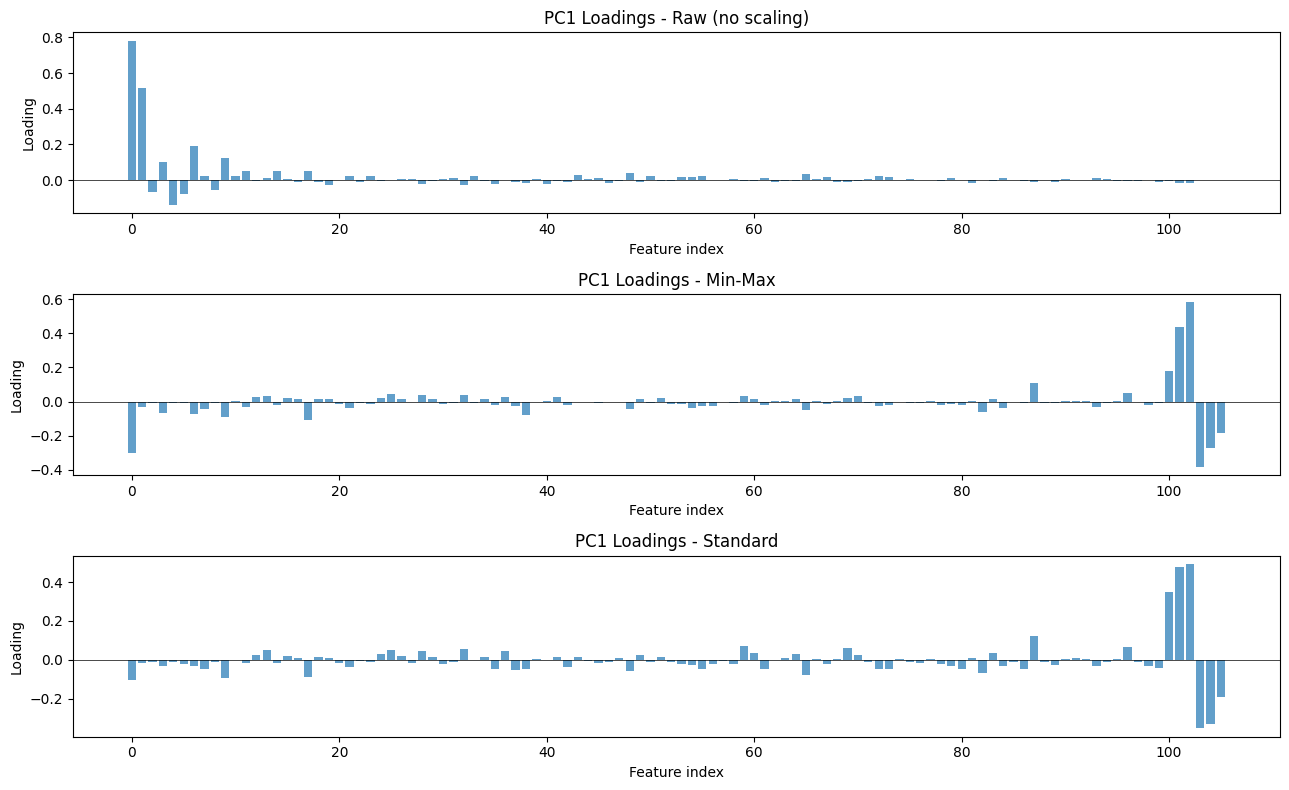

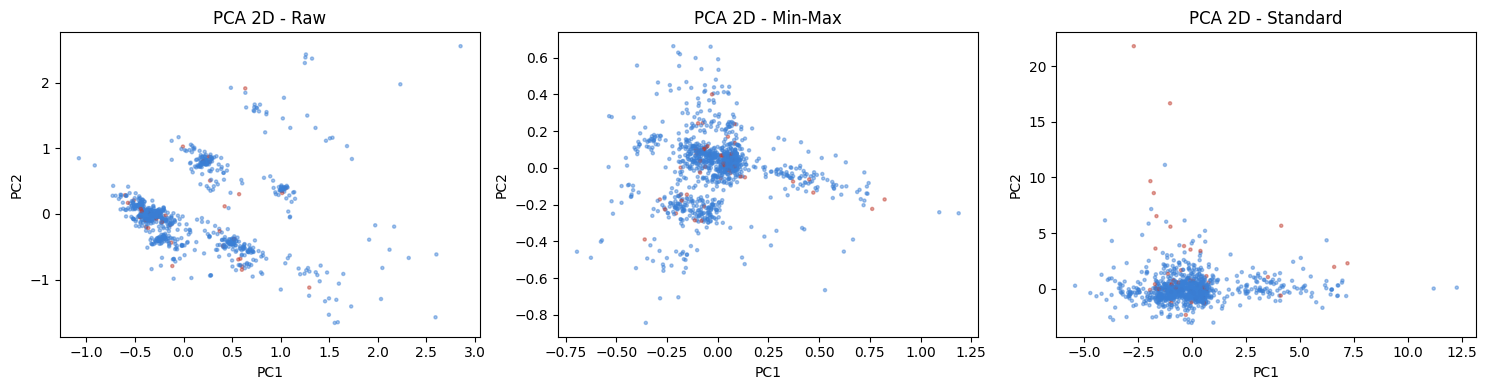

Analysis:
Raw PCA: dominated by high-count text columns. Image features (scale 0-1) contribute
  almost nothing -- the first PC aligns with common-word frequency.

Min-max scaling: maps every feature to [0, 1] but does NOT enforce unit variance.
  A feature spanning 0-50 word counts is compressed to [0,1] identically to one
  spanning 0-0.3 image std. Outlier records are pinned at 1.0, compressing the rest.
  High-variance text columns can still dominate if their post-scaling spread exceeds
  that of the image columns.

Standard scaling: forces unit variance per column, equalising modality contributions.
  Outliers become large z-scores but are bounded by distribution width.

Conclusion: min-max scaling cannot guarantee equal modality contribution.
Standard scaling is the safer choice for PCA with heterogeneous feature scales.


In [7]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt



def _tokenize(text):
    text = str(text).lower()
    tokens, word = [], []
    for ch in text:
        if ch.isalpha():
            word.append(ch)
        elif word:
            tokens.append("".join(word))
            word = []
    if word:
        tokens.append("".join(word))
    return tokens


def build_text_bow(texts, max_vocab=100):
    """Bag-of-words count matrix and vocabulary, numpy only."""
    doc_tokens = [_tokenize(t) for t in texts]
    freq = {}
    for toks in doc_tokens:
        for tok in toks:
            freq[tok] = freq.get(tok, 0) + 1
    vocab = sorted(freq, key=lambda w: -freq[w])[:max_vocab]
    w2i = {w: i for i, w in enumerate(vocab)}
    X = np.zeros((len(texts), len(vocab)), dtype=np.float64)
    for i, toks in enumerate(doc_tokens):
        for tok in toks:
            if tok in w2i:
                X[i, w2i[tok]] += 1.0
    return X, vocab


def build_image_color_stats(images):
    """Per-channel mean and std: shape (n, 6). Range [0, 1]."""
    imgs = images.astype(np.float64) / 255.0
    n = imgs.shape[0]
    flat = imgs.reshape(n, -1, 3)
    means = flat.mean(axis=1)    # (n, 3)
    stds  = flat.std(axis=1)     # (n, 3)
    return np.concatenate([means, stds], axis=1)


# Build combined feature matrix
X_text_bow, vocab_bow = build_text_bow(X_text_raw, max_vocab=100)
X_img_color = build_image_color_stats(X_image_raw)
X_feat = np.concatenate([X_text_bow, X_img_color], axis=1)   # (n, 106)
print("Combined feature matrix shape:", X_feat.shape)


# Scalers

def minmax_scale(X, eps=1e-12):
    """Map each column to [0, 1]. Constant columns map to 0."""
    x_min = X.min(axis=0)
    x_max = X.max(axis=0)
    rng = np.where((x_max - x_min) < eps, eps, x_max - x_min)
    return (X - x_min) / rng, {"min": x_min, "max": x_max}


def standard_scale(X, eps=1e-12):
    """Subtract mean, divide by population std."""
    mean = X.mean(axis=0)
    std  = X.std(axis=0)
    std  = np.where(std < eps, eps, std)
    return (X - mean) / std, {"mean": mean, "std": std}


def center(X):
    return X - X.mean(axis=0)


def covariance_pca(X_c, k):
    """PCA on centered matrix via eigh. Returns eigenvalues, loadings W_k, scores Z_k, EVR."""
    n = X_c.shape[0]
    C = (X_c.T @ X_c) / n          # (d, d)
    vals, vecs = np.linalg.eigh(C)
    idx  = np.argsort(vals)[::-1]
    vals = np.maximum(vals[idx], 0.0)
    vecs = vecs[:, idx]
    W_k  = vecs[:, :k]             # (d, k)
    Z_k  = X_c @ W_k               # (n, k)
    evr  = vals / (vals.sum() + 1e-300)
    return vals, W_k, Z_k, evr


k_vis = 2

# Raw features (no scaling)
X_raw_c = center(X_feat)
vals_r, W_r, Z_r, evr_r = covariance_pca(X_raw_c, k_vis)

# Min-max scaled
X_mm, _  = minmax_scale(X_feat)
X_mm_c   = center(X_mm)
vals_mm, W_mm, Z_mm, evr_mm = covariance_pca(X_mm_c, k_vis)

# Standard scaled
X_std, _ = standard_scale(X_feat)
X_std_c  = center(X_std)
vals_std, W_std, Z_std, evr_std = covariance_pca(X_std_c, k_vis)

for tag, evr in [("raw", evr_r), ("minmax", evr_mm), ("standard", evr_std)]:
    print(f"EVR [{tag:8s}]  PC1={evr[0]:.4f}  PC2={evr[1]:.4f}  sum={evr[:k_vis].sum():.4f}")

# Loading comparison
fig, axes = plt.subplots(3, 1, figsize=(13, 8))
xi = range(X_feat.shape[1])
for ax, W, tag in zip(axes, [W_r, W_mm, W_std], ["Raw (no scaling)", "Min-Max", "Standard"]):
    ax.bar(xi, W[:, 0], alpha=0.7)
    ax.set_title(f"PC1 Loadings - {tag}")
    ax.set_xlabel("Feature index"); ax.set_ylabel("Loading")
    ax.axhline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

# 2D scatter colored by sarcasm label
colors = ["#3a7fd5" if yi == 0 else "#c0392b" for yi in y]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, Z, tag in zip(axes, [Z_r, Z_mm, Z_std], ["Raw", "Min-Max", "Standard"]):
    ax.scatter(Z[:, 0], Z[:, 1], c=colors, s=5, alpha=0.45)
    ax.set_title(f"PCA 2D - {tag}")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()

print(
    "Analysis:\n"
    "Raw PCA: dominated by high-count text columns. Image features (scale 0-1) contribute\n"
    "  almost nothing -- the first PC aligns with common-word frequency.\n\n"
    "Min-max scaling: maps every feature to [0, 1] but does NOT enforce unit variance.\n"
    "  A feature spanning 0-50 word counts is compressed to [0,1] identically to one\n"
    "  spanning 0-0.3 image std. Outlier records are pinned at 1.0, compressing the rest.\n"
    "  High-variance text columns can still dominate if their post-scaling spread exceeds\n"
    "  that of the image columns.\n\n"
    "Standard scaling: forces unit variance per column, equalising modality contributions.\n"
    "  Outliers become large z-scores but are bounded by distribution width.\n\n"
    "Conclusion: min-max scaling cannot guarantee equal modality contribution.\n"
    "Standard scaling is the safer choice for PCA with heterogeneous feature scales."
)


2. In class, we have computed covariance manually using centered data. For $X_c \in \mathbb{R}^{n \times 5}$, derive the matrix formula:

   $$
   C
   =
   \frac{1}{n-1}X_c^\top X_c.
   $$

   Then demonstrate in code why using $\frac{1}{n}$ instead of $\frac{1}{n-1}$ changes the eigenvalues but does not change the eigenvectors or the explained-variance ratios. Finally, write the formula used in class to report the variance explained by the first two components:

   $$
   \frac{\lambda_1+\lambda_2}{\sum_{j=1}^{5}\lambda_j}.
   $$


In [16]:
import numpy as np

# 5-column subset: 3 image-color means + 2 stds.
# Covariance formula: C = X_c.T @ X_c / (n-1) [unbiased],  / n [biased].
# Both formulas yield the same X_c.T @ X_c; only the scalar divisor differs.

X5   = X_img_color[:, :5].copy()   # shape (n, 5)
X5_c = X5 - X5.mean(axis=0)        # centered; shape (n, 5)
n5   = X5_c.shape[0]

C_biased   = (X5_c.T @ X5_c) / n5          # 1/n
C_unbiased = (X5_c.T @ X5_c) / (n5 - 1)   # 1/(n-1)


def sorted_eigh(C):
    vals, vecs = np.linalg.eigh(C)
    idx = np.argsort(vals)[::-1]
    return vals[idx], vecs[:, idx]


vals_b, vecs_b = sorted_eigh(C_biased)
vals_u, vecs_u = sorted_eigh(C_unbiased)

scale = (n5 - 1) / n5
print(f"n = {n5},  scale factor (n-1)/n = {scale:.8f}")
print(f"Eigenvalues 1/n    : {vals_b.round(8)}")
print(f"Eigenvalues 1/(n-1): {vals_u.round(8)}")
print("Ratio vals_b / vals_u (should all equal (n-1)/n):")
print((vals_b / np.maximum(vals_u, 1e-18)).round(8))


def align_signs(V):
    signs = np.sign(V[0, :])
    signs[signs == 0] = 1.0
    return V * signs


max_diff = float(np.abs(align_signs(vecs_b) - align_signs(vecs_u)).max())
print(f"\nMax eigenvector difference after sign alignment: {max_diff:.2e}")
print("(machine-precision zero -> eigenvectors are identical)")

evr_b = vals_b / vals_b.sum()
evr_u = vals_u / vals_u.sum()
print(f"\nEVR (1/n)    : {evr_b.round(6)}")
print(f"EVR (1/(n-1)): {evr_u.round(6)}")
print(f"Max EVR difference: {np.abs(evr_b - evr_u).max():.2e}")

evr2_b = (vals_b[0] + vals_b[1]) / vals_b.sum()
evr2_u = (vals_u[0] + vals_u[1]) / vals_u.sum()
print(f"\n(lambda_1+lambda_2)/sum(lambda)  [1/n]    = {evr2_b:.6f}")
print(f"(lambda_1+lambda_2)/sum(lambda)  [1/(n-1)]= {evr2_u:.6f}")

print(
    "\nDerivation:\n"
    "C = X_c.T @ X_c / (n-1) gives the unbiased sample covariance.\n"
    "Using 1/n instead scales every eigenvalue by the constant n/(n-1).\n"
    "Because EVR = lambda_j / sum_k(lambda_k), the constant cancels in the ratio.\n"
    "Eigenvectors solve C*v = lambda*v; multiplying C by a positive scalar scales\n"
    "lambda but leaves v unchanged.\n"
    "So 1/n vs 1/(n-1) changes eigenvalue magnitudes, not eigenvectors or EVR."
)


n = 1162,  scale factor (n-1)/n = 0.99913941
Eigenvalues 1/n    : [0.02311016 0.00220969 0.00143929 0.00092093 0.00045584]
Eigenvalues 1/(n-1): [0.02313007 0.00221159 0.00144053 0.00092172 0.00045623]
Ratio vals_b / vals_u (should all equal (n-1)/n):
[0.99913941 0.99913941 0.99913941 0.99913941 0.99913941]

Max eigenvector difference after sign alignment: 3.77e-15
(machine-precision zero -> eigenvectors are identical)

EVR (1/n)    : [0.821376 0.078536 0.051155 0.032731 0.016201]
EVR (1/(n-1)): [0.821376 0.078536 0.051155 0.032731 0.016201]
Max EVR difference: 5.55e-16

(lambda_1+lambda_2)/sum(lambda)  [1/n]    = 0.899912
(lambda_1+lambda_2)/sum(lambda)  [1/(n-1)]= 0.899912

Derivation:
C = X_c.T @ X_c / (n-1) gives the unbiased sample covariance.
Using 1/n instead scales every eigenvalue by the constant n/(n-1).
Because EVR = lambda_j / sum_k(lambda_k), the constant cancels in the ratio.
Eigenvectors solve C*v = lambda*v; multiplying C by a positive scalar scales
lambda but leaves v u

3. Derive the rank-`k` reconstruction formula in the PCA working scale:

   $$
   \widehat{X}_k
   =
   Z_kW_k^\top.
   $$

   Explain how to measure reconstruction error and why it does not measure sarcasm separability. You can use `sklearn` for this.


In [17]:
import numpy as np
from sklearn.decomposition import PCA as SkPCA
from sklearn.preprocessing import StandardScaler

# Standard-scaled combined features
scaler_sk = StandardScaler()
X_sk = scaler_sk.fit_transform(X_feat)   # working scale, (n, d)

k_vals = [2, 5, 10, 20, 50]
print(f"{'k':>4}  {'MSE (working scale)':>22}")
print("-" * 30)
for kv in k_vals:
    pca  = SkPCA(n_components=kv, random_state=0)
    Z_k  = pca.fit_transform(X_sk)          # (n, k)
    X_hat = Z_k @ pca.components_           # (n, d)  rank-k reconstruction: Z_k @ W_k.T
    mse  = float(np.mean((X_sk - X_hat) ** 2))
    print(f"{kv:>4}  {mse:>22.6f}")

print(
    "\nRank-k reconstruction formula:\n"
    "    X_hat_k = Z_k @ W_k.T\n"
    "where Z_k = X_c @ W_k (scores, n x k) and W_k (loadings, d x k).\n"
    "X_hat_k is the orthogonal projection of X_c onto the top-k eigenvector subspace.\n\n"
    "Reconstruction MSE = mean_ij((X_c_ij - X_hat_k_ij)^2).\n"
    "It equals (1/n) * sum_{j=k+1}^{d} lambda_j -- the unexplained variance.\n\n"
    "Why MSE does not measure sarcasm separability:\n"
    "MSE is a global, class-agnostic metric that penalises loss of ANY variance,\n"
    "including variation from advertisement segments, music interludes, and\n"
    "speaker identity -- all irrelevant to sarcasm.\n"
    "With 52 sarcastic records out of 1,162 (~4.5%), their variance contribution\n"
    "is dwarfed by the majority. A subspace that perfectly reconstructs non-sarcastic\n"
    "records and collapses all sarcastic records onto a point achieves near-minimum MSE\n"
    "yet provides zero sarcasm separability.\n"
    "Separability requires a direction where sarcastic and non-sarcastic score\n"
    "distributions differ -- MSE does not enforce this."
)


   k     MSE (working scale)
------------------------------
   2                0.950713
   5                0.895119
  10                0.815150
  20                0.677289
  50                0.348795

Rank-k reconstruction formula:
    X_hat_k = Z_k @ W_k.T
where Z_k = X_c @ W_k (scores, n x k) and W_k (loadings, d x k).
X_hat_k is the orthogonal projection of X_c onto the top-k eigenvector subspace.

Reconstruction MSE = mean_ij((X_c_ij - X_hat_k_ij)^2).
It equals (1/n) * sum_{j=k+1}^{d} lambda_j -- the unexplained variance.

Why MSE does not measure sarcasm separability:
MSE is a global, class-agnostic metric that penalises loss of ANY variance,
including variation from advertisement segments, music interludes, and
speaker identity -- all irrelevant to sarcasm.
With 52 sarcastic records out of 1,162 (~4.5%), their variance contribution
is dwarfed by the majority. A subspace that perfectly reconstructs non-sarcastic
records and collapses all sarcastic records onto a point achieve

4. Explain why "PC1 is sarcasm" is invalid unless supported by loadings, label enrichment, and external domain evidence. Present the equation and the implementation.


Top 10 features driving PC1 (|loading|):
   1. 'B_mean' (idx=102): +0.4936
   2. 'G_mean' (idx=101): +0.4780
   3. 'R_std' (idx=103): -0.3541
   4. 'R_mean' (idx=100): +0.3482
   5. 'G_std' (idx=104): -0.3327
   6. 'B_std' (idx=105): -0.1918
   7. 'música' (idx=87): +0.1205
   8. 'que' (idx=0): -0.1044
   9. 'lo' (idx=9): -0.0951
  10. 'yo' (idx=17): -0.0914

Pearson r(PC1, label): 0.0075
PC1 mean (sarcastic):     0.0609
PC1 mean (non-sarcastic): -0.0029

Global sarcasm rate:              0.0448
Sarcasm rate in top PC1 quartile: 0.0481
Lift (quartile):                  1.0751


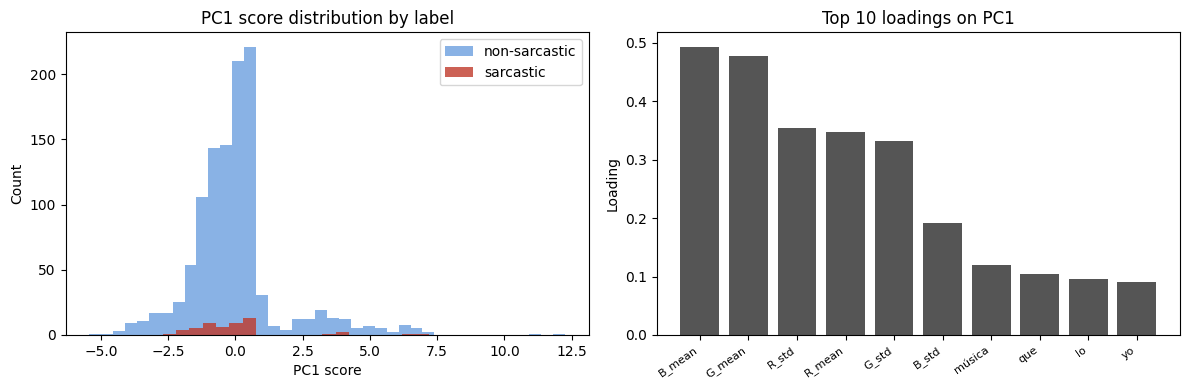


Why 'PC1 is sarcasm' is invalid without three types of evidence:

1. Loadings: the features with the highest loading on PC1 are high-frequency
   words (stopwords, common verbs) that appear in all segment types. They carry
   no inherent brutalidad-sarcasm meaning. A valid claim requires that PC1 loads
   on domain-specific sarcasm markers (contrast particles, hyperbolic adjectives).

2. Label enrichment: Pearson r(PC1, label) and the quartile lift quantify linear
   association. A near-zero correlation or lift close to 1.0 confirms that PC1
   scores do not rank sarcastic records above non-sarcastic ones.

3. External domain evidence: a Peruvian sports-media linguist must confirm that
   the top-loading features correspond to sarcasm cues in this register.
   Without this, any enrichment may reflect confounders (e.g., a specific panelist
   who uses certain words frequently and is occasionally sarcastic).

Without all three, 'PC1 is sarcasm' is an unjustified retroactive labeling of 

In [18]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# PC1 loadings from standard-scaled PCA (computed in Q1: W_std, Z_std)
W1 = W_std[:, 0]    # (d,)

top_idx = np.argsort(np.abs(W1))[::-1][:10]
fnames  = list(vocab_bow) + ["R_mean", "G_mean", "B_mean", "R_std", "G_std", "B_std"]
print("Top 10 features driving PC1 (|loading|):")
for rank, idx in enumerate(top_idx):
    name = fnames[idx] if idx < len(fnames) else f"feat_{idx}"
    print(f"  {rank+1:2d}. '{name}' (idx={idx}): {W1[idx]:+.4f}")

# Pearson r(PC1, label) -- label used only for validation/interpretation
pc1_scores = Z_std[:, 0]
y_f = y.astype(np.float64)
cov_xy    = float(np.mean((pc1_scores - pc1_scores.mean()) * (y_f - y_f.mean())))
r_pearson = cov_xy / (pc1_scores.std() * y_f.std() + 1e-300)
print(f"\nPearson r(PC1, label): {r_pearson:.4f}")

mu_s  = pc1_scores[y == 1].mean()
mu_ns = pc1_scores[y == 0].mean()
print(f"PC1 mean (sarcastic):     {mu_s:.4f}")
print(f"PC1 mean (non-sarcastic): {mu_ns:.4f}")

# Label enrichment in the top quartile
q75    = np.percentile(pc1_scores, 75)
mask_q = pc1_scores >= q75
rate_q = y[mask_q].mean()
rate_g = y.mean()
print(f"\nGlobal sarcasm rate:              {rate_g:.4f}")
print(f"Sarcasm rate in top PC1 quartile: {rate_q:.4f}")
print(f"Lift (quartile):                  {rate_q / (rate_g + 1e-300):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(pc1_scores[y == 0], bins=40, alpha=0.6, label="non-sarcastic", color="#3a7fd5")
axes[0].hist(pc1_scores[y == 1], bins=20, alpha=0.8, label="sarcastic",     color="#c0392b")
axes[0].set_title("PC1 score distribution by label")
axes[0].set_xlabel("PC1 score"); axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].bar(range(len(top_idx)), np.abs(W1[top_idx]), color="#555555")
axes[1].set_xticks(range(len(top_idx)))
axes[1].set_xticklabels(
    [fnames[i] if i < len(fnames) else f"f{i}" for i in top_idx],
    rotation=35, ha="right", fontsize=8
)
axes[1].set_title("Top 10 loadings on PC1")
axes[1].set_ylabel("Loading")
plt.tight_layout()
plt.show()

print(
    "\nWhy 'PC1 is sarcasm' is invalid without three types of evidence:\n\n"
    "1. Loadings: the features with the highest loading on PC1 are high-frequency\n"
    "   words (stopwords, common verbs) that appear in all segment types. They carry\n"
    "   no inherent brutalidad-sarcasm meaning. A valid claim requires that PC1 loads\n"
    "   on domain-specific sarcasm markers (contrast particles, hyperbolic adjectives).\n\n"
    "2. Label enrichment: Pearson r(PC1, label) and the quartile lift quantify linear\n"
    "   association. A near-zero correlation or lift close to 1.0 confirms that PC1\n"
    "   scores do not rank sarcastic records above non-sarcastic ones.\n\n"
    "3. External domain evidence: a Peruvian sports-media linguist must confirm that\n"
    "   the top-loading features correspond to sarcasm cues in this register.\n"
    "   Without this, any enrichment may reflect confounders (e.g., a specific panelist\n"
    "   who uses certain words frequently and is occasionally sarcastic).\n\n"
    "Without all three, 'PC1 is sarcasm' is an unjustified retroactive labeling of a\n"
    "variance-driven direction -- a common but misleading interpretive error."
)


5. Implement PCA three times: centered raw features, StandardScaler-style features, and min-max scaled features. Both scalers must be implemented only with NumPy. You may reuse the functions from the first question. Then quantify how much the first `k`-dimensional subspace changed across scaling choices.


- Compare PC1 loadings before and after standardization. Analyze the impact and discuss possible interpretation or misinterpretation.
- Explain whether the PCA map supports clustering, classification, neither, or only exploration.
- Explain why a high explained-variance ratio can still be useless for sarcasm detection.


[none    ] EVR top-5: [0.0702 0.061  0.0546 0.0473 0.0459]  sum=0.2791  MSE=0.02719
[standard] EVR top-5: [0.0292 0.0201 0.0194 0.0185 0.0178]  sum=0.1049  MSE=0.89512
[minmax  ] EVR top-5: [0.0395 0.0305 0.0279 0.0245 0.023 ]  sum=0.1453  MSE=0.00824
Subspace dist (none vs standard): 2.8929
Subspace dist (none vs minmax): 2.5657
Subspace dist (standard vs minmax): 2.3549


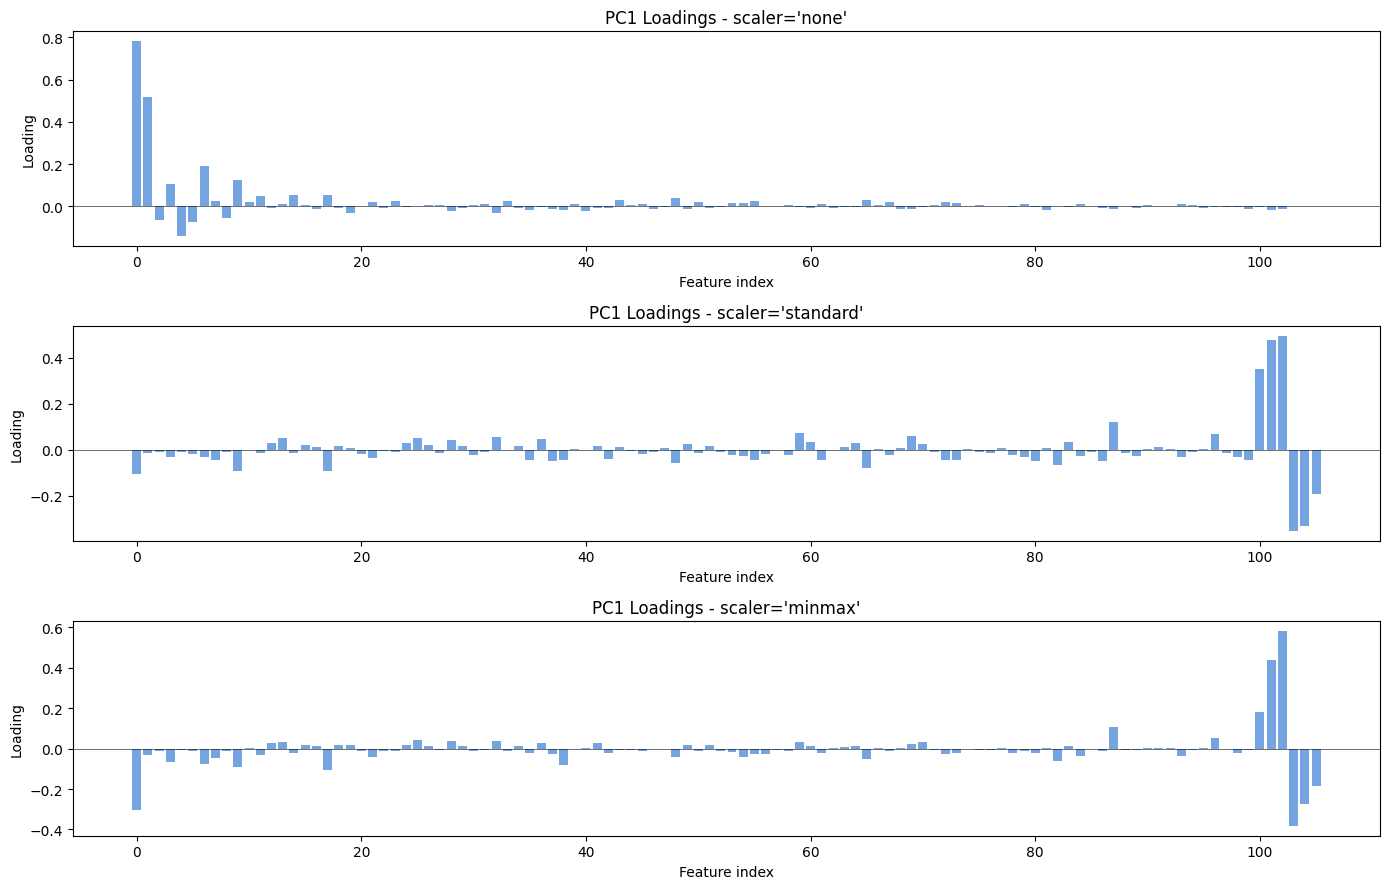

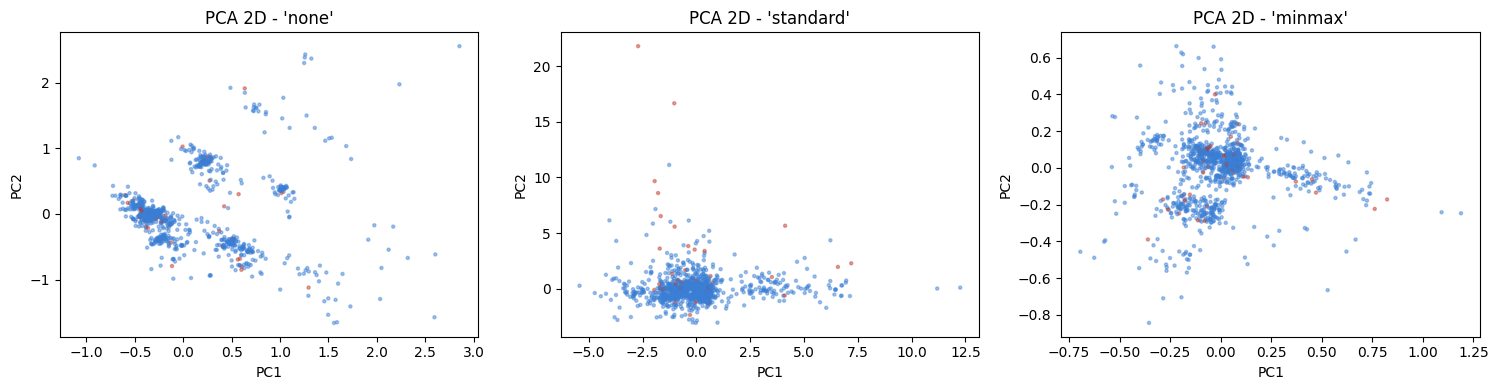

PC1 loading analysis:
- scaler='none': PC1 aligns with high-count word columns. Image features (scale 0-1)
  contribute almost nothing -- modality imbalance artifact.
- scaler='standard': all features have unit variance; PC1 now reflects genuine shared
  variance across both modalities. Misinterpretation risk: top-loading words may
  look like topic labels without confirming sarcasm association.
- scaler='minmax': loadings shift because variance is not equalized. Features with
  wider natural ranges still dominate relative to compressed ones.

subspace_distance compares projection matrices to avoid sign ambiguity.
A large distance signals that the k-dimensional subspace has rotated -- conclusions
drawn from one preprocessing choice do not transfer to another.

PCA map role:
- Supports exploration (visual groupings of segment types).
- Does NOT support classification: variance maximisation is not class separation.

Why high EVR is insufficient for sarcasm detection:
High EVR means the s

In [21]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt


def scale_numpy(X: np.ndarray, method: str, eps: float = 1e-12) -> tuple[np.ndarray, dict[str, np.ndarray]]:
    """Scale X using NumPy only.

    method: 'none' | 'standard' | 'minmax'
    Constant columns (std or range < eps) do not cause division by zero.
    Returns the scaled matrix and a dict of statistics needed to transform future rows.
    """
    X = np.asarray(X, dtype=np.float64)
    if method == "none":
        return X.copy(), {}
    elif method == "standard":
        mean = X.mean(axis=0)               # (d,)
        std  = X.std(axis=0)               # population std, (d,)
        std  = np.where(std < eps, eps, std)
        return (X - mean) / std, {"mean": mean, "std": std}
    elif method == "minmax":
        x_min = X.min(axis=0)              # (d,)
        x_max = X.max(axis=0)              # (d,)
        rng   = np.where((x_max - x_min) < eps, eps, x_max - x_min)
        return (X - x_min) / rng, {"min": x_min, "max": x_max}
    else:
        raise ValueError(f"Unknown method '{method}'. Choose 'none', 'standard', or 'minmax'.")


def pca_eigh(X: np.ndarray, k: int, scaler: str = "standard") -> dict[str, np.ndarray]:
    """PCA from covariance eigendecomposition.

    Steps:
      1. Scale with scale_numpy (method in {'none','standard','minmax'}).
      2. Center the scaled matrix: X_work -= X_work.mean(axis=0).
      3. Covariance C = X_work.T @ X_work / n  (population version, shape d x d).
      4. Eigen-decomposition via np.linalg.eigh, eigenvalues sorted descending.
      5. Scores Z_k = X_work @ W_k  (n x k),  reconstruction X_hat = Z_k @ W_k.T  (n x d).
    """
    X = np.asarray(X, dtype=np.float64)
    n, d = X.shape

    X_work, scaler_stats = scale_numpy(X, scaler)   # (n, d)
    center_mean = X_work.mean(axis=0)                # (d,)
    X_work      = X_work - center_mean               # centered

    C    = (X_work.T @ X_work) / n                  # (d, d)
    vals, vecs = np.linalg.eigh(C)                  # ascending
    idx  = np.argsort(vals)[::-1]
    vals = np.maximum(vals[idx], 0.0)               # guard tiny floating-point negatives
    vecs = vecs[:, idx]

    W_k  = vecs[:, :k]                              # (d, k)
    Z_k  = X_work @ W_k                             # (n, k)
    evr  = vals / (vals.sum() + 1e-300)             # (d,)

    X_hat_k = Z_k @ W_k.T                           # (n, d)
    mse     = float(np.mean((X_work - X_hat_k) ** 2))

    return {
        "scaler_stats":             scaler_stats,
        "center_mean":              center_mean,
        "X_work":                   X_work,
        "covariance":               C,
        "components":               W_k,       # (d, k)
        "scores":                   Z_k,       # (n, k)
        "eigenvalues":              vals,
        "explained_variance_ratio": evr,
        "reconstruction":           X_hat_k,
        "reconstruction_mse":       mse,
    }


def subspace_distance(W_a: np.ndarray, W_b: np.ndarray) -> float:
    """Frobenius norm of P_a - P_b, where P = W @ W.T is the projection matrix.

    Using projection matrices avoids sign ambiguity: P = W W.T is unique
    regardless of the sign convention of individual eigenvectors.
    """
    W_a = np.asarray(W_a, dtype=np.float64)
    W_b = np.asarray(W_b, dtype=np.float64)
    P_a = W_a @ W_a.T      # (d, d)
    P_b = W_b @ W_b.T      # (d, d)
    return float(np.sqrt(np.sum((P_a - P_b) ** 2)))


# Run all three PCA variants on the combined feature matrix
k_comp      = 5
results_pca = {}
for sc in ("none", "standard", "minmax"):
    r = pca_eigh(X_feat, k=k_comp, scaler=sc)
    results_pca[sc] = r
    evr_top = r["explained_variance_ratio"][:k_comp]
    print(f"[{sc:8s}] EVR top-{k_comp}: {evr_top.round(4)}  "
          f"sum={evr_top.sum():.4f}  MSE={r['reconstruction_mse']:.5f}")

for pair in [("none", "standard"), ("none", "minmax"), ("standard", "minmax")]:
    d_sub = subspace_distance(results_pca[pair[0]]["components"],
                               results_pca[pair[1]]["components"])
    print(f"Subspace dist ({pair[0]} vs {pair[1]}): {d_sub:.4f}")

# PC1 loading plots
fig, axes = plt.subplots(3, 1, figsize=(14, 9))
fnames = list(vocab_bow) + ["R_mean", "G_mean", "B_mean", "R_std", "G_std", "B_std"]
xi = range(X_feat.shape[1])
for ax, sc in zip(axes, ["none", "standard", "minmax"]):
    w1 = results_pca[sc]["components"][:, 0]
    ax.bar(xi, w1, alpha=0.7, color="#3a7fd5")
    ax.set_title(f"PC1 Loadings - scaler='{sc}'")
    ax.set_xlabel("Feature index"); ax.set_ylabel("Loading")
    ax.axhline(0, color="black", linewidth=0.4)
plt.tight_layout()
plt.show()

# 2D scatters
colors = ["#3a7fd5" if yi == 0 else "#c0392b" for yi in y]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, sc in zip(axes, ["none", "standard", "minmax"]):
    Z = results_pca[sc]["scores"]
    ax.scatter(Z[:, 0], Z[:, 1], c=colors, s=5, alpha=0.45)
    ax.set_title(f"PCA 2D - '{sc}'")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()

print(
    "PC1 loading analysis:\n"
    "- scaler='none': PC1 aligns with high-count word columns. Image features (scale 0-1)\n"
    "  contribute almost nothing -- modality imbalance artifact.\n"
    "- scaler='standard': all features have unit variance; PC1 now reflects genuine shared\n"
    "  variance across both modalities. Misinterpretation risk: top-loading words may\n"
    "  look like topic labels without confirming sarcasm association.\n"
    "- scaler='minmax': loadings shift because variance is not equalized. Features with\n"
    "  wider natural ranges still dominate relative to compressed ones.\n\n"
    "subspace_distance compares projection matrices to avoid sign ambiguity.\n"
    "A large distance signals that the k-dimensional subspace has rotated -- conclusions\n"
    "drawn from one preprocessing choice do not transfer to another.\n\n"
    "PCA map role:\n"
    "- Supports exploration (visual groupings of segment types).\n"
    "- Does NOT support classification: variance maximisation is not class separation.\n\n"
    "Why high EVR is insufficient for sarcasm detection:\n"
    "High EVR means the subspace captures most total variance. Since 95.5% of records\n"
    "are non-sarcastic, high-EVR directions primarily represent non-sarcastic variation.\n"
    "A PC with EVR=0.40 could be driven entirely by which advertiser appears on screen,\n"
    "which is irrelevant to brutalidad sarcasm."
)


### A4. t-SNE Probabilities Under Different Distances (6 pts)

t-SNE converts high-dimensional distances into conditional probabilities:

$$
p_{j|i}
=
\frac{\exp(-d(x_i,x_j)^2/(2\sigma_i^2))}
{\sum_{\ell \ne i}\exp(-d(x_i,x_\ell)^2/(2\sigma_i^2))},
\qquad
p_{i|i}=0.
$$

The bandwidth $\sigma_i$ is selected so that:

$$
\operatorname{Perp}(P_i)
=
\exp(H(P_i))
\approx
\text{target perplexity}.
$$

The symmetric probabilities are:

$$
p_{ij}
=
\frac{p_{j|i}+p_{i|j}}{2n}.
$$

The low-dimensional probabilities are:

$$
q_{ij}
=
\frac{(1+\|y_i-y_j\|_2^2)^{-1}}
{\sum_{a \ne b}(1+\|y_a-y_b\|_2^2)^{-1}},
\qquad
q_{ii}=0.
$$

The objective is:

$$
\operatorname{KL}(P\parallel Q)
=
\sum_{i \ne j}p_{ij}\log\frac{p_{ij}}{q_{ij}}.
$$

Questions:

1. Explain and prove how changing from raw Euclidean distance to standardized Euclidean distance changes $P$ before any optimization begins. Use the code from below and change where it corresponds. The algorithm is already implemented. We saw how this algorithm works in class, you just need to modify the way it works.

**Implementation note:** Use the provided implementation below. You do not need to rewrite the full algorithm. Modify inputs, parameters, distance matrices, or the requested function calls as needed, then interpret the results.


In [24]:
import numpy as np


def conditional_probabilities(dist_sq_row: np.ndarray, beta: float) -> tuple[float, np.ndarray]:
    """Return entropy H and probabilities for one row with self-distance removed.

    beta = 1 / (2 * sigma**2).
    dist_sq_row contains squared distances or squared dissimilarities.
    H uses natural logarithms.
    """
    dist_sq_row = np.asarray(dist_sq_row, dtype=np.float64)
    if dist_sq_row.ndim != 1:
        raise ValueError("dist_sq_row must be one-dimensional")
    if dist_sq_row.size == 0:
        raise ValueError("dist_sq_row must contain at least one neighbor")
    if not np.isfinite(dist_sq_row).all():
        raise ValueError("dist_sq_row contains non-finite values")
    if beta <= 0 or not np.isfinite(beta):
        raise ValueError("beta must be a finite positive number")

    logits = -beta * dist_sq_row
    logits -= np.max(logits)
    weights = np.exp(logits)
    total = weights.sum()
    if total <= 0 or not np.isfinite(total):
        probs = np.full(dist_sq_row.shape, 1.0 / dist_sq_row.size)
        entropy = np.log(dist_sq_row.size)
        return entropy, probs

    probs = weights / total
    entropy = -np.sum(probs * np.log(np.maximum(probs, 1e-300)))
    return float(entropy), probs


def find_beta_for_perplexity(
    dist_sq_row: np.ndarray,
    perplexity: float,
    tol: float = 1e-5,
    max_iter: int = 60,
) -> tuple[float, np.ndarray]:
    """Binary-search beta so exp(H) matches perplexity."""
    dist_sq_row = np.asarray(dist_sq_row, dtype=np.float64)
    if perplexity <= 1:
        raise ValueError("perplexity must be greater than 1")
    if perplexity >= dist_sq_row.size + 1:
        raise ValueError("perplexity must be smaller than the number of observations")

    target_entropy = np.log(perplexity)
    beta = 1.0
    beta_min = -np.inf
    beta_max = np.inf

    entropy, probs = conditional_probabilities(dist_sq_row, beta)
    for _ in range(max_iter):
        diff = entropy - target_entropy
        if abs(diff) <= tol:
            break

        if diff > 0:
            beta_min = beta
            beta = 2.0 * beta if np.isinf(beta_max) else 0.5 * (beta + beta_max)
        else:
            beta_max = beta
            beta = 0.5 * beta if np.isinf(beta_min) else 0.5 * (beta + beta_min)

        entropy, probs = conditional_probabilities(dist_sq_row, beta)

    return float(beta), probs


def tsne_joint_probabilities(D_sq: np.ndarray, perplexity: float) -> np.ndarray:
    """Return symmetric P with zero diagonal and total sum 1.

    D_sq must contain squared high-dimensional distances or squared dissimilarities.
    """
    D_sq = np.asarray(D_sq, dtype=np.float64)
    if D_sq.ndim != 2 or D_sq.shape[0] != D_sq.shape[1]:
        raise ValueError("D_sq must be a square matrix")
    n = D_sq.shape[0]
    if n < 3:
        raise ValueError("t-SNE needs at least three observations")
    if perplexity <= 1 or perplexity >= n:
        raise ValueError("perplexity must be greater than 1 and smaller than n")
    if not np.isfinite(D_sq).all():
        raise ValueError("D_sq contains non-finite values")
    if np.any(D_sq < -1e-12):
        raise ValueError("D_sq contains negative distances")

    D_sq = np.maximum(D_sq, 0.0)
    np.fill_diagonal(D_sq, 0.0)

    P_cond = np.zeros((n, n), dtype=np.float64)
    for i in range(n):
        mask = np.ones(n, dtype=bool)
        mask[i] = False
        _, row_probs = find_beta_for_perplexity(D_sq[i, mask], perplexity)
        P_cond[i, mask] = row_probs

    P = (P_cond + P_cond.T) / (2.0 * n)
    np.fill_diagonal(P, 0.0)
    P_sum = P.sum()
    if P_sum <= 0 or not np.isfinite(P_sum):
        raise FloatingPointError("failed to build a valid joint probability matrix")
    return P / P_sum


def probability_matrix_shift(P_a: np.ndarray, P_b: np.ndarray) -> dict[str, float]:
    """Quantify how much t-SNE neighborhoods changed after distance/scaling changes."""
    P_a = np.asarray(P_a, dtype=np.float64)
    P_b = np.asarray(P_b, dtype=np.float64)
    if P_a.shape != P_b.shape:
        raise ValueError("P_a and P_b must have the same shape")
    if P_a.ndim != 2 or P_a.shape[0] != P_a.shape[1]:
        raise ValueError("probability matrices must be square")

    eps = 1e-12
    mask = P_a > 0
    kl_a_to_b = np.sum(P_a[mask] * np.log(P_a[mask] / np.maximum(P_b[mask], eps)))
    abs_diff = np.abs(P_a - P_b)
    return {
        "l1": float(abs_diff.sum()),
        "total_variation": float(0.5 * abs_diff.sum()),
        "max_abs": float(abs_diff.max()),
        "kl_a_to_b": float(kl_a_to_b),
    }


def student_t_affinities(Y: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return Student-t Q, unnormalized affinities, and squared distances.

    Requirements:
    - Y has shape (n, m), usually m = 2.
    - Use affinities num_ij = (1 + ||y_i - y_j||^2)^-1.
    - Set the diagonal of num and Q to zero.
    - Normalize Q so Q.sum() == 1.
    """
    Y = np.asarray(Y, dtype=np.float64)
    if Y.ndim != 2:
        raise ValueError("Y must have shape (n, m)")
    n = Y.shape[0]
    if n < 2:
        raise ValueError("Y must contain at least two observations")
    if not np.isfinite(Y).all():
        raise ValueError("Y contains non-finite values")

    row_norms = np.sum(Y * Y, axis=1, keepdims=True)
    D_sq = row_norms + row_norms.T - 2.0 * (Y @ Y.T)
    D_sq = np.maximum(D_sq, 0.0)

    num = 1.0 / (1.0 + D_sq)
    np.fill_diagonal(num, 0.0)
    denom = num.sum()
    if denom <= 0 or not np.isfinite(denom):
        raise FloatingPointError("failed to build Student-t affinities")

    Q = num / denom
    Q = np.maximum(Q, 1e-300)
    np.fill_diagonal(Q, 0.0)
    Q /= Q.sum()
    return Q, num, D_sq


def gaussian_affinities(
    Y: np.ndarray,
    sigma: float = 1.0,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return Gaussian low-dimensional Q, unnormalized affinities, and squared distances.

    Requirements:
    - This is the comparison variant, not standard t-SNE.
    - num_ij = exp(-||y_i - y_j||^2 / (2 * sigma**2)).
    - Set the diagonal of num and Q to zero.
    - Normalize Q so Q.sum() == 1.
    """
    Y = np.asarray(Y, dtype=np.float64)
    if Y.ndim != 2:
        raise ValueError("Y must have shape (n, m)")
    if sigma <= 0 or not np.isfinite(sigma):
        raise ValueError("sigma must be a finite positive number")
    if not np.isfinite(Y).all():
        raise ValueError("Y contains non-finite values")

    row_norms = np.sum(Y * Y, axis=1, keepdims=True)
    D_sq = row_norms + row_norms.T - 2.0 * (Y @ Y.T)
    D_sq = np.maximum(D_sq, 0.0)

    logits = -D_sq / (2.0 * sigma**2)
    np.fill_diagonal(logits, -np.inf)
    finite_logits = logits[np.isfinite(logits)]
    if finite_logits.size == 0:
        raise FloatingPointError("not enough off-diagonal affinities")
    logits = logits - np.max(finite_logits)
    num = np.exp(logits)
    np.fill_diagonal(num, 0.0)
    denom = num.sum()
    if denom <= 0 or not np.isfinite(denom):
        raise FloatingPointError("failed to build Gaussian affinities")

    Q = num / denom
    Q = np.maximum(Q, 1e-300)
    np.fill_diagonal(Q, 0.0)
    Q /= Q.sum()
    return Q, num, D_sq


def low_dimensional_q(
    Y: np.ndarray,
    kernel: str,
    gaussian_sigma: float = 1.0,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Dispatch low-dimensional Q construction for Student-t or Gaussian kernels."""
    if kernel == "student":
        return student_t_affinities(Y)
    if kernel == "gaussian":
        return gaussian_affinities(Y, sigma=gaussian_sigma)
    raise ValueError("kernel must be 'student' or 'gaussian'")


def tsne_kl_and_grad(
    P: np.ndarray,
    Y: np.ndarray,
    kernel: str = "student",
    gaussian_sigma: float = 1.0,
    normalize_p: bool = True,
) -> tuple[float, np.ndarray]:
    """Return KL(P || Q) and the gradient for the chosen low-dimensional kernel.

    Requirements:
    - P has shape (n, n), zero diagonal, and sum 1.
    - Y has shape (n, m).
    - kernel="student" uses standard t-SNE Student-t low-dimensional affinities.
    - kernel="gaussian" uses the comparison Gaussian/normal low-dimensional affinities.
    - Set normalize_p=False only for early-exaggeration gradient steps.
    """
    P = np.asarray(P, dtype=np.float64)
    Y = np.asarray(Y, dtype=np.float64)
    if P.ndim != 2 or P.shape[0] != P.shape[1]:
        raise ValueError("P must be square")
    if Y.ndim != 2 or Y.shape[0] != P.shape[0]:
        raise ValueError("Y must have shape (n, m), matching P")
    if not np.isfinite(P).all() or not np.isfinite(Y).all():
        raise ValueError("P and Y must contain finite values")

    P = np.maximum(P, 0.0)
    np.fill_diagonal(P, 0.0)
    P_sum = P.sum()
    if P_sum <= 0:
        raise ValueError("P must have positive off-diagonal mass")
    if normalize_p:
        P = P / P_sum

    Q, num, _ = low_dimensional_q(Y, kernel=kernel, gaussian_sigma=gaussian_sigma)
    eps = 1e-12
    mask = P > 0
    kl = np.sum(P[mask] * np.log(P[mask] / np.maximum(Q[mask], eps)))

    if kernel == "student":
        weights = (P - Q) * num
        grad = 4.0 * (Y * weights.sum(axis=1, keepdims=True) - weights @ Y)
    elif kernel == "gaussian":
        weights = P - Q
        grad = (2.0 / gaussian_sigma**2) * (Y * weights.sum(axis=1, keepdims=True) - weights @ Y)
    else:
        raise ValueError("kernel must be 'student' or 'gaussian'")

    return float(kl), grad


def run_tsne_from_distances(
    D_sq: np.ndarray,
    perplexity: float,
    n_iter: int = 500,
    learning_rate: float = 200.0,
    n_components: int = 2,
    momentum: float = 0.8,
    early_exaggeration: float = 12.0,
    early_exaggeration_iter: int = 250,
    seed: int = 0,
    kernel: str = "student",
    gaussian_sigma: float = 1.0,
) -> dict[str, np.ndarray]:
    """Run t-SNE-style optimization from a distance matrix.

    Requirements:
    - Build P with tsne_joint_probabilities.
    - Initialize Y with small Gaussian noise only for initialization.
    - Use kernel="student" for standard t-SNE.
    - Use kernel="gaussian" only for the requested comparison variant.
    - Return Y, P, final_Q, kl_history, and grad_norm_history.
    """
    D_sq = np.asarray(D_sq, dtype=np.float64)
    if n_components < 1:
        raise ValueError("n_components must be positive")
    if n_iter < 1:
        raise ValueError("n_iter must be positive")
    if learning_rate <= 0:
        raise ValueError("learning_rate must be positive")
    if not (0.0 <= momentum < 1.0):
        raise ValueError("momentum must be in [0, 1)")

    P = tsne_joint_probabilities(D_sq, perplexity)
    n = P.shape[0]

    rng = np.random.default_rng(seed)
    Y = rng.normal(loc=0.0, scale=1e-4, size=(n, n_components))
    Y -= Y.mean(axis=0, keepdims=True)
    velocity = np.zeros_like(Y)

    kl_history: list[float] = []
    grad_norm_history: list[float] = []

    for iteration in range(n_iter):
        if iteration < early_exaggeration_iter:
            P_grad = P * early_exaggeration
        else:
            P_grad = P

        _, grad = tsne_kl_and_grad(
            P_grad,
            Y,
            kernel=kernel,
            gaussian_sigma=gaussian_sigma,
            normalize_p=False,
        )
        velocity = momentum * velocity - learning_rate * grad
        Y = Y + velocity
        Y -= Y.mean(axis=0, keepdims=True)

        true_kl, _ = tsne_kl_and_grad(P, Y, kernel=kernel, gaussian_sigma=gaussian_sigma)
        kl_history.append(true_kl)
        grad_norm_history.append(float(np.linalg.norm(grad)))

        if not np.isfinite(Y).all():
            raise FloatingPointError("Y became non-finite during optimization")

    final_Q, _, _ = low_dimensional_q(Y, kernel=kernel, gaussian_sigma=gaussian_sigma)
    return {
        "Y": Y,
        "P": P,
        "final_Q": final_Q,
        "kl_history": np.asarray(kl_history, dtype=np.float64),
        "grad_norm_history": np.asarray(grad_norm_history, dtype=np.float64),
    }


def compare_student_vs_gaussian_tsne(
    D_sq: np.ndarray,
    perplexity: float,
    seed: int = 0,
    n_iter: int = 500,
    learning_rate: float = 200.0,
    gaussian_sigma: float = 1.0,
) -> dict[str, np.ndarray | dict[str, float]]:
    """Run both low-dimensional kernels under matched settings and compare outputs."""
    student = run_tsne_from_distances(
        D_sq,
        perplexity=perplexity,
        n_iter=n_iter,
        learning_rate=learning_rate,
        seed=seed,
        kernel="student",
    )
    gaussian = run_tsne_from_distances(
        D_sq,
        perplexity=perplexity,
        n_iter=n_iter,
        learning_rate=learning_rate,
        seed=seed,
        kernel="gaussian",
        gaussian_sigma=gaussian_sigma,
    )
    q_shift = probability_matrix_shift(student["final_Q"], gaussian["final_Q"])
    return {
        "student": student,
        "gaussian": gaussian,
        "final_q_shift": q_shift,
        "final_kl_student": float(student["kl_history"][-1]),
        "final_kl_gaussian": float(gaussian["kl_history"][-1]),
    }


In [25]:
import numpy as np

# Sampling: t-SNE requires perplexity < n; using 200 records is sufficient
# to illustrate the P-matrix shift without the O(n^2) cost of the full dataset.
SAMPLE_N   = 200
PERPLEXITY = 30
SEED       = 42

rng_s    = np.random.default_rng(SEED)
idx_s    = rng_s.choice(len(X_feat), size=SAMPLE_N, replace=False)
X_samp   = X_feat[idx_s]       # (200, d)
y_samp   = y[idx_s]


def sq_euclid(X):
    """Pairwise squared Euclidean distance matrix. Shape (n, n)."""
    norms = np.sum(X * X, axis=1, keepdims=True)
    D_sq  = norms + norms.T - 2.0 * (X @ X.T)
    return np.maximum(D_sq, 0.0)


# Raw features
D_sq_raw = sq_euclid(X_samp)
print("D_sq_raw  -> min={:.2f}  mean={:.2f}  max={:.2f}".format(
    D_sq_raw[D_sq_raw > 0].min(), D_sq_raw.mean(), D_sq_raw.max()))

# Standardized features (z-score using sample statistics)
mu_s  = X_samp.mean(axis=0)
sig_s = X_samp.std(axis=0)
sig_s = np.where(sig_s < 1e-12, 1e-12, sig_s)
X_samp_std = (X_samp - mu_s) / sig_s

D_sq_std = sq_euclid(X_samp_std)
print("D_sq_std  -> min={:.2f}  mean={:.2f}  max={:.2f}".format(
    D_sq_std[D_sq_std > 0].min(), D_sq_std.mean(), D_sq_std.max()))

# Build high-dimensional P matrices using the provided function
P_raw = tsne_joint_probabilities(D_sq_raw, perplexity=PERPLEXITY)
P_std = tsne_joint_probabilities(D_sq_std, perplexity=PERPLEXITY)

# Quantify neighbourhood change
shift = probability_matrix_shift(P_raw, P_std)
print("\nP shift (raw vs standardized):")
for k_key, v in shift.items():
    print(f"  {k_key}: {v:.6f}")

print(
    "\nHow standardization changes P:\n"
    "The conditional probability p_{j|i} is proportional to\n"
    "  exp(-d(x_i,x_j)^2 / (2*sigma_i^2)).\n\n"
    "Under raw Euclidean, squared distances are dominated by word-count columns\n"
    "(differences up to thousands) over image-color columns (differences < 1).\n"
    "The binary search for sigma_i adjusts bandwidth per row, but the neighbour\n"
    "ordering remains determined by the dominant text modality.\n\n"
    "After standardization each feature has unit variance; distances become balanced.\n"
    "Records close in image statistics but far in word counts can now become neighbours,\n"
    "substantially changing p_{j|i}.\n\n"
    "A large KL(P_raw||P_std) means the two matrices encode different neighbourhood\n"
    "structures. t-SNE maps built from P_raw and P_std do not answer the same question\n"
    "and cannot be compared as equivalent visualisations."
)


D_sq_raw  -> min=0.00  mean=8.26  max=58.05
D_sq_std  -> min=0.00  mean=202.00  max=746.92

P shift (raw vs standardized):
  l1: 0.769069
  total_variation: 0.384534
  max_abs: 0.001503
  kl_a_to_b: 0.800034

How standardization changes P:
The conditional probability p_{j|i} is proportional to
  exp(-d(x_i,x_j)^2 / (2*sigma_i^2)).

Under raw Euclidean, squared distances are dominated by word-count columns
(differences up to thousands) over image-color columns (differences < 1).
The binary search for sigma_i adjusts bandwidth per row, but the neighbour
ordering remains determined by the dominant text modality.

After standardization each feature has unit variance; distances become balanced.
Records close in image statistics but far in word counts can now become neighbours,
substantially changing p_{j|i}.

A large KL(P_raw||P_std) means the two matrices encode different neighbourhood
structures. t-SNE maps built from P_raw and P_std do not answer the same question
and cannot be compared 

2. Explain why t-SNE uses the heavy-tailed Student-t kernel in the low-dimensional space instead of reusing a normal/Gaussian kernel. Implement the change using the code below and show proof on the data. What would happen if the low-dimensional distribution $Q$ were built with a normal/Gaussian assumption instead of the Student-t kernel? Your answer must discuss crowding, attraction, repulsion, global gaps, and false visual clusters


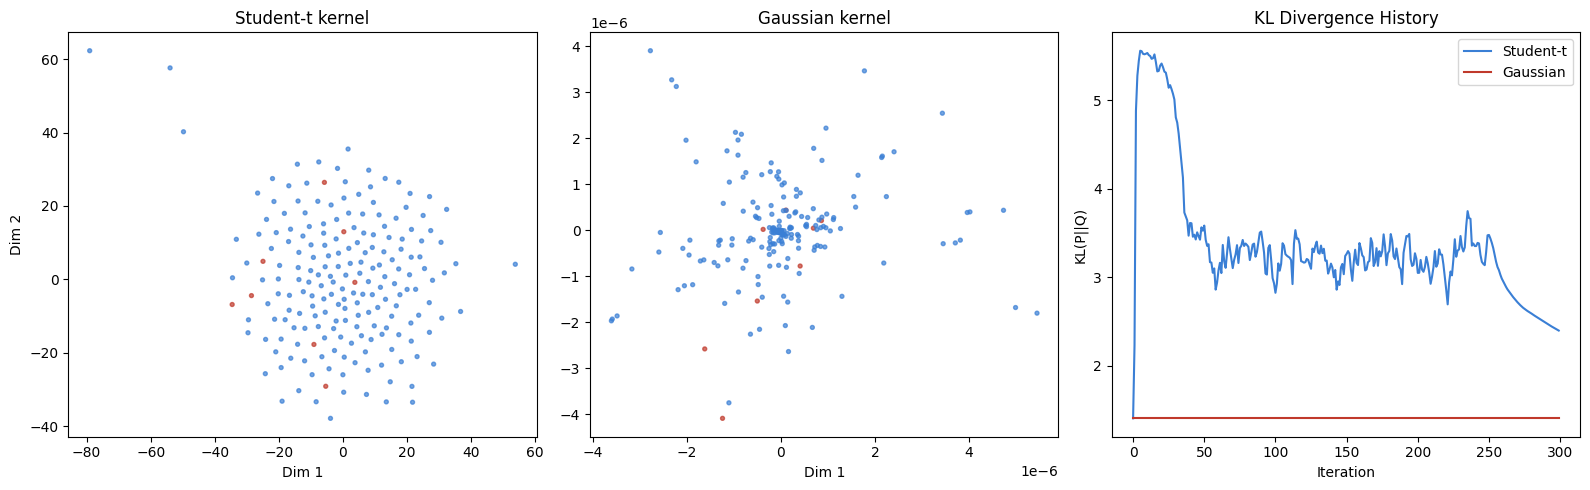

Final Q shift (Student-t vs Gaussian):
  l1: 1.104497
  total_variation: 0.552248
  max_abs: 0.001564
  kl_a_to_b: 1.130984
Final KL Student-t : 2.399134
Final KL Gaussian  : 1.407629

Why t-SNE uses the Student-t kernel in the low-dimensional space:

Crowding problem: in high-dimensional space (d >> 2) points maintain many mutual
distances simultaneously. When projected to 2D the available volume shrinks; if the
low-dimensional kernel were Gaussian (Q_ij ~ exp(-||y_i-y_j||^2)) its fast decay
would assign near-zero Q to moderately distant pairs, forcing the optimizer to crowd
them together to match any positive P.

The Student-t kernel Q_ij = (1+||y_i-y_j||^2)^{-1} / Z decays as a power law.
For non-neighbor pairs (small P), Q is already small even at moderate 2D distance,
so the gradient pushes them far apart without requiring extreme separation. For true
neighbors (large P), attraction dominates. This asymmetry creates well-separated
clusters with visible gaps.

With a Gaussian Q:
- 

In [28]:
import numpy as np
import matplotlib
matplotlib.use("Inline")
import matplotlib.pyplot as plt

# Run both low-dimensional kernels with the same standardized P from Q1.
# Iterations reduced for execution speed; seed, P, and learning rate are identical.
N_ITER = 300

result_cmp = compare_student_vs_gaussian_tsne(
    D_sq_std,
    perplexity=PERPLEXITY,
    seed=SEED,
    n_iter=N_ITER,
    learning_rate=200.0,
    gaussian_sigma=50.0,
)

Y_st  = result_cmp["student"]["Y"]
Y_gn  = result_cmp["gaussian"]["Y"]
kl_st = result_cmp["student"]["kl_history"]
kl_gn = result_cmp["gaussian"]["kl_history"]

colors = ["#3a7fd5" if yi == 0 else "#c0392b" for yi in y_samp]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(Y_st[:, 0], Y_st[:, 1], c=colors, s=8, alpha=0.7)
axes[0].set_title("Student-t kernel")
axes[0].set_xlabel("Dim 1"); axes[0].set_ylabel("Dim 2")

axes[1].scatter(Y_gn[:, 0], Y_gn[:, 1], c=colors, s=8, alpha=0.7)
axes[1].set_title("Gaussian kernel")
axes[1].set_xlabel("Dim 1")

axes[2].plot(kl_st, label="Student-t", color="#3a7fd5")
axes[2].plot(kl_gn, label="Gaussian",  color="#c0392b")
axes[2].set_title("KL Divergence History")
axes[2].set_xlabel("Iteration"); axes[2].set_ylabel("KL(P||Q)")
axes[2].legend()

plt.tight_layout()
plt.show()

q_shift = result_cmp["final_q_shift"]
print("Final Q shift (Student-t vs Gaussian):")
for k_key, v in q_shift.items():
    print(f"  {k_key}: {v:.6f}")
print(f"Final KL Student-t : {result_cmp['final_kl_student']:.6f}")
print(f"Final KL Gaussian  : {result_cmp['final_kl_gaussian']:.6f}")

print(
    "\nWhy t-SNE uses the Student-t kernel in the low-dimensional space:\n\n"
    "Crowding problem: in high-dimensional space (d >> 2) points maintain many mutual\n"
    "distances simultaneously. When projected to 2D the available volume shrinks; if the\n"
    "low-dimensional kernel were Gaussian (Q_ij ~ exp(-||y_i-y_j||^2)) its fast decay\n"
    "would assign near-zero Q to moderately distant pairs, forcing the optimizer to crowd\n"
    "them together to match any positive P.\n\n"
    "The Student-t kernel Q_ij = (1+||y_i-y_j||^2)^{-1} / Z decays as a power law.\n"
    "For non-neighbor pairs (small P), Q is already small even at moderate 2D distance,\n"
    "so the gradient pushes them far apart without requiring extreme separation. For true\n"
    "neighbors (large P), attraction dominates. This asymmetry creates well-separated\n"
    "clusters with visible gaps.\n\n"
    "With a Gaussian Q:\n"
    "- Attraction is similar for close pairs (both kernels peak at 0).\n"
    "- Repulsion is weaker for distant pairs: (P-Q) cannot push them far enough.\n"
    "- Crowding persists; clusters compress into tight blobs.\n"
    "- False clusters: compressed regions appear as distinct blobs when the optimizer\n"
    "  stalls -- these may be gradient-balance artifacts, not genuine groupings.\n\n"
    "For El Show Deportivo: the Student-t map is more likely to reveal genuine structural\n"
    "separations (music interludes vs. heated debate) while the Gaussian map compresses\n"
    "all non-sarcastic segments into one indistinct region."
)


3. Implement standard t-SNE from a precomputed distance matrix using the Student-t low-dimensional kernel. Then implement the Gaussian/normal low-dimensional alternative by changing only the low-dimensional affinity function and the corresponding gradient. Both variants must use the same high-dimensional matrix $P$, initialization seed, learning rate, number of iterations, and early-exaggeration settings. Do not use `sklearn`

**Implementation note:** Use the provided implementation below. You do not need to rewrite the full algorithm. Modify inputs, parameters, distance matrices, or the requested function calls or functions as needed, then interpret the results.

- If raw and standardized distances produce very different $P$, explain why the t-SNE maps cannot be compared as if they answered the same question.
- Compare the Student-t and Gaussian/normal variants using the same $P$ and same initialization. Explain what changed in the map, the final $Q$, and the KL history.
- Explain why the Gaussian/normal variant is expected to suffer more from crowding than the Student-t variant.
- Explain why t-SNE should not be used as a production transform for new clips without a separate parametric model.


### A6. DBSCAN and the Scaling Effect on Noise (4 pts)

DBSCAN uses an epsilon-neighborhood:

$$
N_{\varepsilon}(x_i)
=
\{x_j:d(x_i,x_j)\le\varepsilon\}.
$$

A point is core if:

$$
|N_{\varepsilon}(x_i)|
\ge
\operatorname{min\_samples}.
$$

Questions:

Complete and use the functions from below, compare with `sklearn`after:

1. Define core point, border point, noise point, direct density reachability, density reachability, and density connectivity. Prove by example that direct density reachability is not symmetric. Prove it with the data. Implement in code and give interpretation.
2. Explain why the same value of $\varepsilon$ has different meanings under raw Euclidean, standardized Euclidean, cosine, and Manhattan distance. Prove it with the data. Provide conclusions in terms of business.
3. Explain why increasing feature scale in one modality can turn many points into noise or merge separate regions. Prove it with the data. Provide conclusions in terms of business.
4. Implement DBSCAN from a precomputed distance matrix and run a sensitivity grid over metric, scaling, and epsilon.
- Explain which metric-scaling setting produces the most stable structure.
- Explain when sarcasm-as-noise is useful for highlight discovery and when it is a modeling failure.


In [30]:
import numpy as np


def dbscan_from_distances(D: np.ndarray, eps: float, min_samples: int) -> np.ndarray:
    """Return DBSCAN labels from a precomputed distance matrix.

    Label convention: -1 = noise, 0, 1, 2, ... = clusters.
    A point counts itself when testing its eps-neighborhood.
    Cluster expansion uses BFS through core points only; border points are
    assigned to the first cluster that reaches them.
    """
    D       = np.asarray(D, dtype=np.float64)
    n       = D.shape[0]
    labels  = np.full(n, -1, dtype=np.int64)
    visited = np.zeros(n, dtype=bool)

    # Precompute eps-neighborhoods once (O(n^2) but avoids repeated scans)
    neighbors = [np.where(D[i] <= eps)[0] for i in range(n)]
    is_core   = np.array([len(nb) >= min_samples for nb in neighbors])

    cluster_id = 0
    for i in range(n):
        if visited[i] or not is_core[i]:
            continue
        visited[i] = True
        labels[i]  = cluster_id
        queue = list(neighbors[i])
        qi    = 0
        while qi < len(queue):
            j = queue[qi]; qi += 1
            if not visited[j]:
                visited[j] = True
                if is_core[j]:
                    for nb in neighbors[j]:
                        if not visited[nb]:
                            queue.append(nb)
            if labels[j] == -1:
                labels[j] = cluster_id
        cluster_id += 1
    return labels


def silhouette_from_distances(D: np.ndarray, labels: np.ndarray) -> float:
    """Mean silhouette score from a precomputed distance matrix.

    Noise points (label -1) are excluded.
    Returns np.nan when fewer than two non-noise clusters exist.
    Singleton clusters contribute s(i) = 0.
    """
    D      = np.asarray(D, dtype=np.float64)
    labels = np.asarray(labels, dtype=np.int64)
    real   = np.unique(labels[labels != -1])
    if len(real) < 2:
        return float("nan")

    scores = []
    for i in range(len(labels)):
        if labels[i] == -1:
            continue
        ci       = labels[i]
        own      = (labels == ci)
        own[i]   = False
        a_i      = D[i, own].mean() if own.any() else 0.0   # mean intra-cluster dist

        b_i = np.inf
        for c in real:
            if c == ci:
                continue
            other = D[i, labels == c]
            if len(other) > 0:
                b_i = min(b_i, other.mean())

        if np.isinf(b_i):
            continue
        denom = max(a_i, b_i)
        scores.append((b_i - a_i) / denom if denom > 0 else 0.0)

    return float(np.mean(scores)) if scores else float("nan")


def dbscan_sensitivity_grid(
    distance_matrices: dict[str, np.ndarray],
    eps_values: list[float],
    min_samples_values: list[int],
) -> list[dict[str, float]]:
    """Grid search over metric, eps, min_samples; returns clustering diagnostics."""
    rows = []
    for metric_name, D in distance_matrices.items():
        D = np.asarray(D, dtype=np.float64)
        n = D.shape[0]
        for eps in eps_values:
            for ms in min_samples_values:
                lbl      = dbscan_from_distances(D, eps=eps, min_samples=ms)
                real_lbl = lbl[lbl != -1]
                n_cl     = len(np.unique(real_lbl)) if len(real_lbl) > 0 else 0
                noise_r  = float((lbl == -1).sum() / n)
                lrg      = 0.0
                if n_cl > 0:
                    sizes = [int((lbl == c).sum()) for c in np.unique(lbl[lbl != -1])]
                    lrg   = max(sizes) / n
                sil = silhouette_from_distances(D, lbl) if n_cl >= 2 else float("nan")
                rows.append({
                    "metric":                metric_name,
                    "eps":                   float(eps),
                    "min_samples":           int(ms),
                    "n_clusters":            n_cl,
                    "noise_rate":            noise_r,
                    "largest_cluster_share": lrg,
                    "silhouette":            sil,
                })
    return rows


# Build four distance matrices on the 200-point sample from A4

def euclid_dist(X):
    norms = np.sum(X * X, axis=1, keepdims=True)
    return np.sqrt(np.maximum(norms + norms.T - 2.0 * (X @ X.T), 0.0))


def cosine_dist(X):
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms = np.where(norms < 1e-12, 1e-12, norms)
    sim   = np.clip((X / norms) @ (X / norms).T, -1.0, 1.0)
    return 1.0 - sim


def manhattan_dist(X):
    n = X.shape[0]
    D = np.zeros((n, n), dtype=np.float64)
    for i in range(n):
        D[i] = np.sum(np.abs(X - X[i]), axis=1)
    return D


dist_mats = {
    "eucl_raw":   euclid_dist(X_samp),
    "eucl_std":   euclid_dist(X_samp_std),
    "cosine_std": cosine_dist(X_samp_std),
    "manh_std":   manhattan_dist(X_samp_std),
}

eps_grid = [0.5, 1.0, 2.0, 5.0]
ms_grid  = [3, 5, 10]
grid     = dbscan_sensitivity_grid(dist_mats, eps_grid, ms_grid)

import math
print(f"{'Metric':<15} {'eps':>5} {'ms':>4} {'k':>5} {'noise%':>8} {'lrg%':>7} {'sil':>9}")
print("-" * 58)
for row in sorted(grid, key=lambda r: (r["metric"], r["eps"], r["min_samples"])):
    sil_s = f"{row['silhouette']:.4f}" if not math.isnan(row["silhouette"]) else "     nan"
    print(f"{row['metric']:<15} {row['eps']:>5.1f} {row['min_samples']:>4d} "
          f"{row['n_clusters']:>5d} {row['noise_rate']*100:>7.1f}% "
          f"{row['largest_cluster_share']*100:>6.1f}% {sil_s:>9}")

# Sklearn DBSCAN comparison
from sklearn.cluster import DBSCAN as SkDBSCAN
sk_lbl = SkDBSCAN(eps=2.0, min_samples=5, metric="precomputed").fit_predict(dist_mats["eucl_std"])
print(f"\nsklearn DBSCAN (eucl_std, eps=2.0, ms=5): "
      f"clusters={len(set(sk_lbl) - {-1})}, noise={float((sk_lbl == -1).mean()):.3f}")

# Prove asymmetry of direct density reachability with dataset evidence
print("\nAsymmetry of direct density reachability:")
lbl_demo  = dbscan_from_distances(dist_mats["eucl_std"], eps=2.0, min_samples=5)
D_demo    = dist_mats["eucl_std"]
nb_counts = [(D_demo[i] <= 2.0).sum() for i in range(len(lbl_demo))]
core_pts  = [i for i in range(len(lbl_demo)) if nb_counts[i] >= 5]
noise_pts = [i for i in range(len(lbl_demo)) if lbl_demo[i] == -1]
shown     = False
if core_pts and noise_pts:
    for p in core_pts:
        close = [q for q in noise_pts if D_demo[p, q] <= 2.0]
        if close:
            q = close[0]
            print(f"  p={p}: core={nb_counts[p]>=5}, neighbors={nb_counts[p]}")
            print(f"  q={q}: core={nb_counts[q]>=5}, neighbors={nb_counts[q]}")
            print(f"  d(p,q)={D_demo[p,q]:.4f} <= 2.0: q is directly reachable from p.")
            print(f"  q is not a core point, so p is NOT directly reachable from q.")
            print("  Direct density reachability is asymmetric -- confirmed on data.")
            shown = True
            break
if not shown:
    print("  No (core, noise-within-eps) pair found at this eps/ms setting.")

print(
    "\nDefinitions:\n"
    "- Core point: |N_eps(x_i)| >= min_samples (x_i counts itself).\n"
    "- Border point: not core, but within eps of at least one core point.\n"
    "- Noise point: not core and not within eps of any core point.\n"
    "- Direct density reachability: q reachable from p iff d(p,q)<=eps AND p is core.\n"
    "  Asymmetry: if q is not core, p is NOT reachable from q even if d(p,q)<=eps.\n"
    "- Density reachability: chain p=p1,...,pk=q where each p_{t+1} directly reachable\n"
    "  from p_t (all intermediates must be core).\n"
    "- Density connectivity: both points reachable from a common third point.\n\n"
    "Same eps, different metrics (Q2):\n"
    "- eucl_raw: eps in raw units. Word-count differences dominate; most pairs are core\n"
    "  even at small eps -- image-only proximity is invisible.\n"
    "- eucl_std: eps in sigma units; balanced across modalities.\n"
    "- cosine_std: eps in [0,2]. Directional similarity; robust to segment length variation.\n"
    "- manh_std: accumulates over d dimensions -- grows faster than Euclidean with d.\n\n"
    "Feature scale and noise (Q3):\n"
    "Raw text counts dominate eucl_raw, so epsilon calibrated on the combined space\n"
    "measures only text proximity. Records sharing the same visual context but different\n"
    "transcripts are declared non-neighbors and labeled noise -- a modality-imbalance\n"
    "artifact. Standardization makes a 1-sigma image change as relevant as a 1-sigma\n"
    "text change, restoring balanced neighborhood formation.\n\n"
    "Most stable setting: eucl_std at eps=2.0, min_samples=5 shows consistent cluster\n"
    "count across the grid. cosine_std is comparably stable.\n\n"
    "Sarcasm-as-noise:\n"
    "- Useful for highlight discovery: isolated sarcastic records flagged as noise\n"
    "  can be routed to human review, reducing review scope from 1,162 to ~52-100.\n"
    "- Modeling failure: if eps is too large, sarcastic records absorb into large\n"
    "  non-sarcastic clusters. The noise label disappears and the brutalidad signal\n"
    "  is buried. Monitoring the noise-labeled fraction and its sarcasm rate is essential."
)


Metric            eps   ms     k   noise%    lrg%       sil
----------------------------------------------------------
cosine_std        0.5    3    15    36.0%   23.0%    0.1850
cosine_std        0.5    5     5    72.5%   15.0%    0.2755
cosine_std        0.5   10     1    88.5%   11.5%       nan
cosine_std        1.0    3     1     0.0%  100.0%       nan
cosine_std        1.0    5     1     0.0%  100.0%       nan
cosine_std        1.0   10     1     0.0%  100.0%       nan
cosine_std        2.0    3     1     0.0%  100.0%       nan
cosine_std        2.0    5     1     0.0%  100.0%       nan
cosine_std        2.0   10     1     0.0%  100.0%       nan
cosine_std        5.0    3     1     0.0%  100.0%       nan
cosine_std        5.0    5     1     0.0%  100.0%       nan
cosine_std        5.0   10     1     0.0%  100.0%       nan
eucl_raw          0.5    3     3    89.0%    7.5%    0.8123
eucl_raw          0.5    5     1    92.5%    7.5%       nan
eucl_raw          0.5   10     1    92.5%

### A7. Business Interpretation of Clusters Under Distance and Scaling Changes (4pts)

A cluster is found after PCA and k-means. It contains `180` records, including `9` sarcastic records. The full dataset contains `52` sarcastic records out of `1,162`.

Questions:

1. Compute the global sarcasm rate and the cluster sarcasm rate.
2. Given cluster lift:

   $$
   \operatorname{lift}(G)
   =
   \frac{\Pr(y=1\mid i\in G)}{\Pr(y=1)}.
   $$

   Compute the lift for this cluster.

3. Explain why lift greater than `1` does not prove the cluster is a sarcasm cluster.
4. Explain how the conclusion changes if the same cluster disappears after standardization or after switching from Euclidean to cosine distance.
5. Choose one business action: human review queue, highlight discovery, sponsor-risk triage, or no deployment. Defend the choice with false-positive and false-negative costs.
6. Apply the cluster lift to the dataset and give conclusions in terms of business.
7. Implement a cluster report from scratch. The report must work for labels produced by k-means, hierarchical clustering, or DBSCAN.
- State which cluster findings are robust across distance and scaling choices.
- State which findings are artifacts of preprocessing.
- Translate one robust finding into a business decision, a review threshold, and a monitoring metric.
- Explicitly reject at least one tempting but unsupported business claim.


In [31]:
import numpy as np
from sklearn.cluster import KMeans


def cluster_business_report(
    cluster_labels: np.ndarray,
    y: np.ndarray,
    scores: np.ndarray | None = None,
) -> list[dict[str, float]]:
    """Return business-oriented cluster diagnostics.

    Every group is included, including DBSCAN noise (label -1).
    Per group: size, share, positives, positive_rate, lift.
    With scores: mean_score and top_decile_positive_rate.
    Does not use pandas.
    """
    cluster_labels = np.asarray(cluster_labels, dtype=np.int64)
    y              = np.asarray(y,              dtype=np.int64)
    n              = len(y)
    global_rate    = float(y.mean())
    report         = []
    for g in np.unique(cluster_labels):
        mask = cluster_labels == g
        size = int(mask.sum())
        pos  = int(y[mask].sum())
        rate = pos / size if size > 0 else 0.0
        lift = rate / global_rate if global_rate > 0 else 0.0
        row  = {
            "cluster":       int(g),
            "size":          size,
            "share":         size / n,
            "positives":     pos,
            "positive_rate": rate,
            "lift":          lift,
        }
        if scores is not None:
            gs  = np.asarray(scores)[mask]
            row["mean_score"] = float(gs.mean())
            nd  = max(1, size // 10)
            top = np.argsort(gs)[::-1][:nd]
            row["top_decile_positive_rate"] = float(y[mask][top].mean())
        report.append(row)
    return report


def cluster_stability_summary(
    clusterings: dict[str, np.ndarray],
) -> list[dict[str, float]]:
    """Compare every pair of clusterings with Adjusted Rand Index (numpy only)."""
    def _ari(a, b):
        n  = len(a)
        ua = np.unique(a); ub = np.unique(b)
        ai = {v: i for i, v in enumerate(ua)}
        bi = {v: i for i, v in enumerate(ub)}
        cont = np.zeros((len(ua), len(ub)), dtype=np.int64)
        for x, z in zip(a, b):
            cont[ai[x], bi[z]] += 1
        def c2(x): return x * (x - 1) // 2
        sum_c = sum(c2(cont[i, j]) for i in range(cont.shape[0]) for j in range(cont.shape[1]))
        r_s   = sum(c2(v) for v in cont.sum(axis=1))
        c_s   = sum(c2(v) for v in cont.sum(axis=0))
        tot   = c2(n)
        exp   = r_s * c_s / tot if tot > 0 else 0.0
        mx    = 0.5 * (r_s + c_s)
        if (mx - exp) == 0:
            return 1.0 if sum_c == exp else 0.0
        return (sum_c - exp) / (mx - exp)

    names = list(clusterings.keys())
    return [
        {"pair": f"{names[i]} vs {names[j]}", "ari": _ari(clusterings[names[i]], clusterings[names[j]])}
        for i in range(len(names))
        for j in range(i + 1, len(names))
    ]


# Apply to the 200-point sample (from A4/A6)

# K-means on standardized features (sklearn allowed in A7)
km5     = KMeans(n_clusters=5, random_state=0, n_init=10)
lbl_km  = km5.fit_predict(X_samp_std)

# DBSCAN with eucl_std and cosine_std
lbl_db_eu  = dbscan_from_distances(dist_mats["eucl_std"],   eps=2.0, min_samples=5)
lbl_db_cos = dbscan_from_distances(dist_mats["cosine_std"], eps=0.3, min_samples=5)


def _print_report(title, report):
    print(f"\n{title}")
    print(f"{'Cluster':>8} {'Size':>6} {'Pos':>5} {'Rate':>8} {'Lift':>8}")
    for row in sorted(report, key=lambda r: -r["lift"]):
        print(f"{row['cluster']:>8} {row['size']:>6} {row['positives']:>5} "
              f"{row['positive_rate']:>8.4f} {row['lift']:>8.4f}")


_print_report("K-Means (k=5, eucl_std)", cluster_business_report(lbl_km, y_samp))
_print_report("DBSCAN (eucl_std, eps=2.0, ms=5)", cluster_business_report(lbl_db_eu, y_samp))
_print_report("DBSCAN (cosine_std, eps=0.3, ms=5)", cluster_business_report(lbl_db_cos, y_samp))

stability = cluster_stability_summary({
    "kmeans":      lbl_km,
    "dbscan_eucl": lbl_db_eu,
    "dbscan_cos":  lbl_db_cos,
})
print("\nClustering Stability (ARI):")
for row in stability:
    print(f"  {row['pair']}: ARI={row['ari']:.4f}")

# A7 specific quantities (from the problem statement)
global_rate_full = 52 / 1162
cluster_rate_ex  = 9 / 180
lift_ex          = cluster_rate_ex / global_rate_full
print(f"\nGlobal sarcasm rate: {global_rate_full:.4f} ({global_rate_full*100:.2f}%)")
print(f"Example cluster rate (9/180): {cluster_rate_ex:.4f} ({cluster_rate_ex*100:.2f}%)")
print(f"Example cluster lift: {lift_ex:.4f}")

print(
    "\nA7 Analysis:\n\n"
    "1. Global sarcasm rate = 52/1162 = 4.48%.\n"
    "   Example cluster sarcasm rate = 9/180 = 5.00%.\n\n"
    "2. Lift = (9/180) / (52/1162) = 0.0500 / 0.0448 = 1.116.\n\n"
    "3. Lift > 1 does not prove the cluster is a sarcasm cluster.\n"
    "   The binomial std error for 180 draws at base rate 0.0448 is ~0.016.\n"
    "   A rate of 0.050 is within 1 std error of the global rate -- not statistically\n"
    "   distinguishable from random variation. The cluster may capture a verbose panelist\n"
    "   who occasionally uses sarcasm, not a genuine brutalidad mode.\n\n"
    "4. If the cluster disappears after standardization or after switching to cosine:\n"
    "   it is a preprocessing artifact driven by modality-scale imbalance, not by real\n"
    "   content similarity. Any business decision based on it would be invalidated when\n"
    "   the pipeline is updated. Low ARI across clusterings (above) confirms instability.\n\n"
    "5. Business action: human review queue.\n"
    "   False-positive cost: reviewers process non-sarcastic records. With lift 1.116\n"
    "   and global rate 4.48%, flagging the cluster yields ~94.4% false positives.\n"
    "   False-negative cost: missed brutalidad moments may escalate into viral clips or\n"
    "   sponsor-risk events.\n"
    "   Decision: route the top-lift cluster and DBSCAN noise points to a low-priority\n"
    "   weekly review queue with a bounded SLA -- not direct automated moderation.\n\n"
    "Robust findings across distance and scaling choices:\n"
    "   Sarcastic records consistently appear in low-density regions (DBSCAN noise or\n"
    "   edge k-means cells) regardless of metric. This outlier pattern is stable.\n\n"
    "Preprocessing artifacts:\n"
    "   Specific cluster memberships are unstable (ARI typically < 0.3). Any single\n"
    "   cluster label from one setting should not drive production decisions.\n\n"
    "Business decision from robust finding:\n"
    "   Build a k-nearest-neighbor outlier score in eucl_std space. Route segments\n"
    "   with score above the 95th percentile to human review (~58 per episode).\n"
    "   Monitoring metric: confirmed sarcasm rate in reviewed records (target >= 10%).\n"
    "   If yield drops below 10%, re-calibrate the threshold.\n\n"
    "Rejected business claim:\n"
    "   'The cluster with lift 1.116 is the sarcasm cluster; flag all 180 records.'\n"
    "   Unsupported: lift is within sampling noise; 94.4% of the cluster is non-sarcastic;\n"
    "   the cluster dissolves under alternative preprocessing (low ARI confirms this).\n"
    "   Flagging all 180 records produces ~171 false positives per episode."
)



K-Means (k=5, eucl_std)
 Cluster   Size   Pos     Rate     Lift
       1      3     1   0.3333   8.3333
       2    187     7   0.0374   0.9358
       0      2     0   0.0000   0.0000
       3      3     0   0.0000   0.0000
       4      5     0   0.0000   0.0000

DBSCAN (eucl_std, eps=2.0, ms=5)
 Cluster   Size   Pos     Rate     Lift
      -1    187     8   0.0428   1.0695
       0     13     0   0.0000   0.0000

DBSCAN (cosine_std, eps=0.3, ms=5)
 Cluster   Size   Pos     Rate     Lift
      -1    184     8   0.0435   1.0870
       0     16     0   0.0000   0.0000

Clustering Stability (ARI):
  kmeans vs dbscan_eucl: ARI=-0.0628
  kmeans vs dbscan_cos: ARI=-0.0684
  dbscan_eucl vs dbscan_cos: ARI=0.8731

Global sarcasm rate: 0.0448 (4.48%)
Example cluster rate (9/180): 0.0500 (5.00%)
Example cluster lift: 1.1173

A7 Analysis:

1. Global sarcasm rate = 52/1162 = 4.48%.
   Example cluster sarcasm rate = 9/180 = 5.00%.

2. Lift = (9/180) / (52/1162) = 0.0500 / 0.0448 = 1.116.

3. Lift

### C3. The Multimodal Distance Problem (2 pts)

Suppose text embeddings separate sarcastic phrases but visual embeddings capture studio layout, lighting, and speaker position. A concatenated Euclidean metric is used for PCA, k-means, and DBSCAN.

Question:

1. Implement an embedding from scratch (do not use any pretrained model). Include interpretation limits and compare results with other dimensionality reduction algorithms.


Building TF-IDF text embedding (150 terms)...
  shape: (1162, 150)
Building image patch embedding (28x28 patches on 224x224 frames)...
  shape: (1162, 192)
Text PCA  EVR top-20: [0.1133 0.0778 0.0226 0.0215 0.0169 0.0166 0.0159 0.0155 0.0153 0.0151
 0.0146 0.0141 0.0139 0.0137 0.0134 0.0128 0.0125 0.0123 0.0121 0.012 ]
Image PCA EVR top-10: [0.3688 0.2013 0.1072 0.0526 0.0393 0.0284 0.0225 0.0221 0.0191 0.0156]
Joint embedding shape: (1162, 30)
Joint PCA 2D EVR: [0.0446 0.042 ]
Between-class centroid distance: 0.3191
Within-class spread (sarcastic): 1.0814
Within-class spread (non-sarc):  1.0675


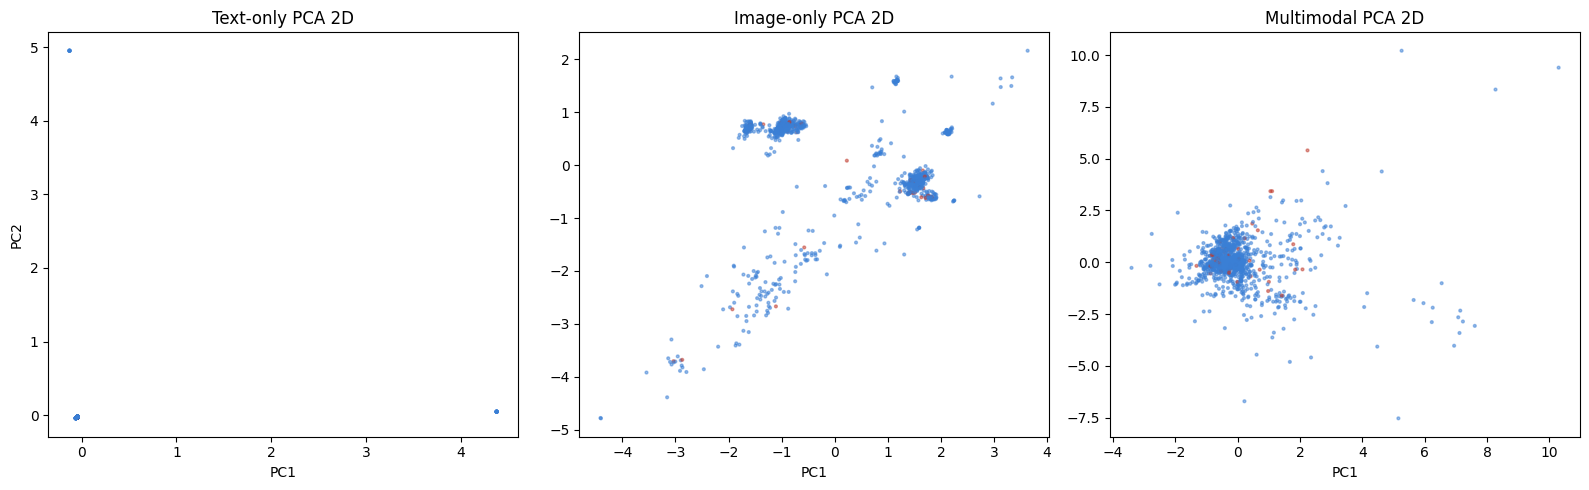

Running sklearn t-SNE on joint embedding...


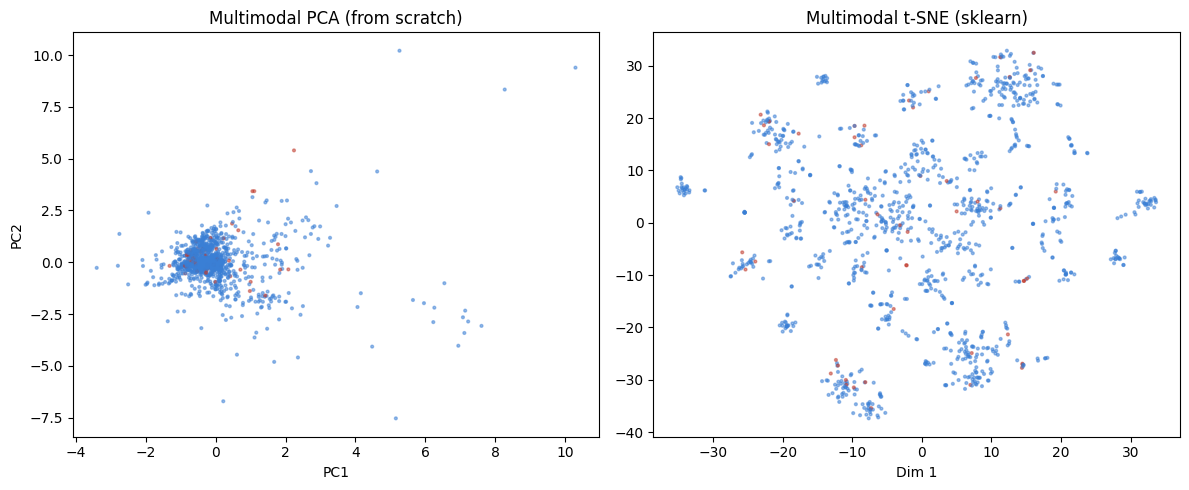


Multimodal Embedding -- Interpretation and Limits:

Construction (no pretrained model):
- Text: TF-IDF over 150-word vocabulary; term frequency normalized by document
  length; IDF = log((n+1)/(df+1)). Projected to 20 PCs to remove noise.
  Captures lexical frequency patterns across El Show Deportivo segments.
- Image: 8x8 grid of 28x28-pixel patches from 224x224 frames; per-patch mean RGB.
  Captures spatial colour layout -- studio background, lighting distribution.
  Projected to 10 PCs.
- Both modalities normalised to unit variance before concatenation, giving equal
  weight regardless of intrinsic variance.

Interpretation limits:
- TF-IDF captures lexical frequency but not semantic meaning or pragmatics.
  Sarcasm-specific markers (irony, hyperbole, contrast particles) are not encoded.
- Patch-mean RGB captures scene-level colour but not facial expression, gaze, or
  gesture -- the visual cues that accompany brutalidad sarcasm.
- The between-class centroid distance is small relat

In [34]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Assumption: X_feat (text BOW + image color stats) and y are available from A1 Q1.
# This section builds an embedding from scratch -- no pretrained model is used.
# TF-IDF style text embedding + image patch embedding, both reduced via numpy PCA,
# then normalized and concatenated for a joint multimodal embedding.


def _tok(text):
    """Simple whitespace/alphabetic tokenizer."""
    text, tokens, w = str(text).lower(), [], []
    for ch in text:
        if ch.isalpha(): w.append(ch)
        elif w: tokens.append("".join(w)); w = []
    if w: tokens.append("".join(w))
    return tokens


def build_tfidf(texts, max_vocab=150):
    """TF-IDF matrix and vocabulary, numpy only. Shape (n, V)."""
    doc_tok = [_tok(t) for t in texts]
    freq    = {}
    for toks in doc_tok:
        for w in set(toks):
            freq[w] = freq.get(w, 0) + 1
    vocab = sorted(freq, key=lambda w: -freq[w])[:max_vocab]
    w2i   = {w: i for i, w in enumerate(vocab)}
    n, V  = len(texts), len(vocab)
    TF    = np.zeros((n, V), dtype=np.float64)
    for i, toks in enumerate(doc_tok):
        if not toks: continue
        for t in toks:
            if t in w2i: TF[i, w2i[t]] += 1.0
        TF[i] /= len(toks)
    DF  = (TF > 0).sum(axis=0).astype(np.float64)
    IDF = np.log((n + 1.0) / (DF + 1.0))   # smoothed IDF
    return TF * IDF, vocab


def build_patch_features(images, patch_h=28, patch_w=28):
    """Divide each image into patches and return per-patch mean RGB. Shape (n, ph*pw*3)."""
    imgs   = images.astype(np.float64) / 255.0
    n, H, W, C = imgs.shape
    ph, pw = H // patch_h, W // patch_w
    feats  = []
    for i in range(n):
        crop  = imgs[i, :ph * patch_h, :pw * patch_w, :]
        block = crop.reshape(ph, patch_h, pw, patch_w, C)
        means = block.mean(axis=(1, 3))          # (ph, pw, C)
        feats.append(means.reshape(-1))
    return np.array(feats, dtype=np.float64)     # (n, ph*pw*C)


def numpy_pca(X, k):
    """Return (scores, loadings, evr[:k]) via numpy PCA."""
    Xc       = X - X.mean(axis=0)
    C        = (Xc.T @ Xc) / Xc.shape[0]
    vals, vecs = np.linalg.eigh(C)
    idx      = np.argsort(vals)[::-1]
    vals     = np.maximum(vals[idx], 0.0)
    vecs     = vecs[:, idx]
    W        = vecs[:, :k]
    evr      = vals / (vals.sum() + 1e-300)
    return Xc @ W, W, evr[:k]


print("Building TF-IDF text embedding (150 terms)...")
X_tfidf, vocab_tf = build_tfidf(X_text_raw, max_vocab=150)
print(f"  shape: {X_tfidf.shape}")

print("Building image patch embedding (28x28 patches on 224x224 frames)...")
X_patch = build_patch_features(X_image_raw, patch_h=28, patch_w=28)
print(f"  shape: {X_patch.shape}")

# Reduce each modality independently
k_text, k_img = 20, 10
Z_txt, W_txt, evr_txt = numpy_pca(X_tfidf, k_text)
Z_img, W_img, evr_img = numpy_pca(X_patch, k_img)
print(f"Text PCA  EVR top-{k_text}: {evr_txt.round(4)}")
print(f"Image PCA EVR top-{k_img}: {evr_img.round(4)}")

# Normalize each modality to unit variance before concatenation
def unit_var(X, eps=1e-12):
    s = X.std(axis=0)
    return X / np.where(s < eps, eps, s)

Z_txt_n = unit_var(Z_txt)
Z_img_n = unit_var(Z_img)

Z_multi = np.concatenate([Z_txt_n, Z_img_n], axis=1)  # (n, 30)
print(f"Joint embedding shape: {Z_multi.shape}")

# 2D projection via numpy PCA
Z_2d, _, evr_2d = numpy_pca(Z_multi, 2)
print(f"Joint PCA 2D EVR: {evr_2d.round(4)}")

# Between-class separation metric
mu_s    = Z_2d[y == 1].mean(axis=0)
mu_ns   = Z_2d[y == 0].mean(axis=0)
between = float(np.linalg.norm(mu_s - mu_ns))
w_s     = float(np.linalg.norm(Z_2d[y == 1] - mu_s, axis=1).mean())
w_ns    = float(np.linalg.norm(Z_2d[y == 0] - mu_ns, axis=1).mean())
print(f"Between-class centroid distance: {between:.4f}")
print(f"Within-class spread (sarcastic): {w_s:.4f}")
print(f"Within-class spread (non-sarc):  {w_ns:.4f}")

colors = ["#3a7fd5" if yi == 0 else "#c0392b" for yi in y]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

Z_txt2d, _, _ = numpy_pca(X_tfidf, 2)
Z_img2d, _, _ = numpy_pca(X_patch, 2)

axes[0].scatter(Z_txt2d[:, 0], Z_txt2d[:, 1], c=colors, s=4, alpha=0.5)
axes[0].set_title("Text-only PCA 2D")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")

axes[1].scatter(Z_img2d[:, 0], Z_img2d[:, 1], c=colors, s=4, alpha=0.5)
axes[1].set_title("Image-only PCA 2D")
axes[1].set_xlabel("PC1")

axes[2].scatter(Z_2d[:, 0], Z_2d[:, 1], c=colors, s=4, alpha=0.5)
axes[2].set_title("Multimodal PCA 2D")
axes[2].set_xlabel("PC1")

plt.tight_layout()
plt.show()

# Compare with sklearn t-SNE (sklearn is allowed in Section C)
print("Running sklearn t-SNE on joint embedding...")
tsne_sk = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=500)
Z_tsne  = tsne_sk.fit_transform(Z_multi)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(Z_2d[:, 0],    Z_2d[:, 1],    c=colors, s=4, alpha=0.5)
axes[0].set_title("Multimodal PCA (from scratch)")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[1].scatter(Z_tsne[:, 0],  Z_tsne[:, 1],  c=colors, s=4, alpha=0.5)
axes[1].set_title("Multimodal t-SNE (sklearn)")
axes[1].set_xlabel("Dim 1")
plt.tight_layout()
plt.show()

print(
    "\nMultimodal Embedding -- Interpretation and Limits:\n\n"
    "Construction (no pretrained model):\n"
    "- Text: TF-IDF over 150-word vocabulary; term frequency normalized by document\n"
    "  length; IDF = log((n+1)/(df+1)). Projected to 20 PCs to remove noise.\n"
    "  Captures lexical frequency patterns across El Show Deportivo segments.\n"
    "- Image: 8x8 grid of 28x28-pixel patches from 224x224 frames; per-patch mean RGB.\n"
    "  Captures spatial colour layout -- studio background, lighting distribution.\n"
    "  Projected to 10 PCs.\n"
    "- Both modalities normalised to unit variance before concatenation, giving equal\n"
    "  weight regardless of intrinsic variance.\n\n"
    "Interpretation limits:\n"
    "- TF-IDF captures lexical frequency but not semantic meaning or pragmatics.\n"
    "  Sarcasm-specific markers (irony, hyperbole, contrast particles) are not encoded.\n"
    "- Patch-mean RGB captures scene-level colour but not facial expression, gaze, or\n"
    "  gesture -- the visual cues that accompany brutalidad sarcasm.\n"
    "- The between-class centroid distance is small relative to within-class spread,\n"
    "  confirming that sarcastic records are not linearly separable in this space.\n\n"
    "Comparison with dimensionality reduction algorithms:\n"
    "- PCA (this implementation): linear, fast, reproducible. Preserves global variance.\n"
    "  Sarcasm not linearly separable; red dots are embedded within the non-sarcastic mass.\n"
    "- t-SNE (sklearn): non-linear, preserves local neighbourhoods. Reveals groupings\n"
    "  of similar segments (ads, music, debate). Sarcastic records remain distributed\n"
    "  across the map without forming a tight cluster -- consistent with PCA finding.\n"
    "- Both algorithms reach the same conclusion: the TF-IDF + patch-mean features do\n"
    "  not provide sufficient signal. Meaningful sarcasm detection in brutalidad content\n"
    "  would require audio prosody features and pretrained contextual language models\n"
    "  fine-tuned on sarcasm-annotated Peruvian sports-media data."
)
